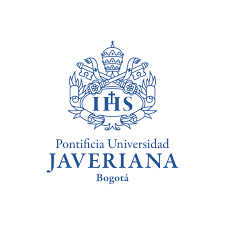
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Métricas y Machine Learning en PySpark**

**Autor**: Juan Camilo Torres Meza

**Fecha de Inicio**: 28 de Abril del 2026

**Fecha actual**: 19 de Mayo del 2026


## **Pasos a realizar:**
    - Levantar sesion Spark
    - Cargar datos de banca
    - Entender los datos
    - Limpiar los datos

In [1]:
## Importar bibliotecas generales
import numpy as nm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Bibliotecas especializadas
from pylab import *

import findspark
findspark.init()
from pyspark.sql import functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext, SparkSession, Row
from pyspark.sql.types import *

from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from sklearn.metrics import roc_curve, auc

In [2]:
### Se requiere levantar la sesión para Trabajar con los Servicios
### Basados en SPARK: Procesamiento Paralelo y Distribuido sobre Grandes Volumenes de Datos
configura = SparkConf()
configura.setAppName("Banca_Torres_SPARK")               #--- Nombre de la aplicación
configura.set("spark.scheduler.mode","FAIR")        #---Configuracion de tipo "FAIR" para que sea justo y equitativo. 
                                                    #---Se requiere que multiples usuarios tengan recursos concurrentemente
configura.set("spark.scheduler.allocation","/Almacen/Spark/conf/fairscheduler.xml")   #---Ubicación xml de la configuración FAIR
configura.setMaster("spark://10.43.97.207:7077")    #---Se configura en la dirección del MASTER
sparkB = SparkSession.builder.config(conf=configura).getOrCreate()    #---Se crea la sesión
print("Sesión creada: Banca Torres")
sparkB

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 18:03:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesión creada: Banca Torres


In [3]:
### Importar el Dataset
df00 = sparkB.read.format("csv").option("header","true").option("sep",";").load("bank-full.csv")
df00.show(5)

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

## **Descripción de datos:**
* AGE: Edad del cliente (años).
* JOB: Tipo de trabajo del cliente.
* MARITAL: Estado civil del cliente (categórico: casado, soltero).
* EDUCATION: Nivel educativo del cliente.
* DEFAULT: Indica si el cliente tiene crédito en incumplimiento (binario: sí/no).
* BALANCE: Balance promedio anual del cliente.
* HOUSING: Indica si el cliente tiene un préstamo hipotecario (binario: sí/no).
* LOAN: Indica si el cliente tiene un préstamo personal (binario: sí/no).
* CONTACT: Tipo de comunicación utilizada para contactar al cliente.
* DAY_OF_WEEK: Último día de la semana en que se contactó al cliente.
* MONTH: Último mes del año en que se contactó al cliente (categórico: enero, febrero,...., diciembre).
* DURATION: Duración de la última llamada en segundos.
* CAMPAIGN: Número de contactos realizados durante esta campaña para este cliente.
* PDAYS: Número de días transcurridos desde el último contacto en una campaña previa (-1 indica que no fue contactado anteriormente).
* PREVIOUS: Número de contactos realizados antes de esta campaña para este cliente.
* POUTCOME: Resultado de la campaña de marketing anterior.
* Y: Variable objetivo. Indica si el cliente se suscribió a un depósito a plazo (binario: sí/no).


In [4]:
### Cantidad de datos
print(f"Se tiene un total de {df00.count()} registros")

[Stage 2:=============================>                             (1 + 1) / 2]

Se tiene un total de 45211 registros


In [5]:
### Conocer los datos
pd.DataFrame(df00.dtypes, columns=['Nombre_columna', 'Tipo_de_dato'])

,Nombre_columna,Tipo_de_dato
0,age,string
1,job,string
2,marital,string
3,education,string
4,default,string
5,balance,string
6,housing,string
7,loan,string
8,contact,string
9,day,string


### Comentarios:
- Se observa que todos los datos se encuentran en tipo "String"
- Se considera la el cambio de tipo de datos a entero
- Se logra observar que la última columna es ETIQUETA

In [6]:
## Copio y cambio los nombres de las columnas

NomOriginal=['age','job','marital','education','default','balance','housing','loan','contact','day','month','duration','campaign','pdays','previous','poutcome','y']
NomNueva=['edad','trabajo','estadoCivil','educacion','credito','balance','hipoteca','prestamo','medioComunicacion','dia','mes','duracion','contactos','ultimoContacto','numeroContactos','resultadoMarketing','plazoFijo']



#### Version
### original --> nueva #Atención que habrá un cambio"
df01 = df00
### Se hará un comprimido para el cambio en un bucle
for antes, nuevo in zip(df01.columns, NomNueva):       #---En el bucle recorremos las columnas anteriores de dfPy01
    df01 = df01.withColumnRenamed(antes, nuevo)      #---Y asignamos en las columnas los nuevos nombres

df01.columns

['edad',
 'trabajo',
 'estadoCivil',
 'educacion',
 'credito',
 'balance',
 'hipoteca',
 'prestamo',
 'medioComunicacion',
 'dia',
 'mes',
 'duracion',
 'contactos',
 'ultimoContacto',
 'numeroContactos',
 'resultadoMarketing',
 'plazoFijo']

In [7]:
### Las siguientes columnas pasan a ser "INT"
colINT = ['edad', 'balance','dia', 'duracion','contactos','ultimoContacto','numeroContactos']

df01 = df01.withColumn("edad", df01.edad.cast("int"))
df01 = df01.withColumn("balance", df01.balance.cast("int"))
df01 = df01.withColumn("dia", df01.dia.cast("int"))
df01 = df01.withColumn("duracion", df01.duracion.cast("int"))
df01 = df01.withColumn("contactos", df01.contactos.cast("int"))
df01 = df01.withColumn("ultimoContacto", df01.ultimoContacto.cast("int"))
df01 = df01.withColumn("numeroContactos", df01.numeroContactos.cast("int"))

In [8]:
## Identificación de tipos de datos con detalle: se hace uso del Pandas
pd.DataFrame(df01.dtypes, columns=['Nombre_columna', 'Tipo_de_dato'])

,Nombre_columna,Tipo_de_dato
0,edad,int
1,trabajo,string
2,estadoCivil,string
3,educacion,string
4,credito,string
5,balance,int
6,hipoteca,string
7,prestamo,string
8,medioComunicacion,string
9,dia,int


In [9]:
## Se revisa el balance del dataset. La idea es conocer si hay posibilidades de SESGO
total = df01.count()
df_Y = df01.groupBy("plazoFijo").count()

auxPD = df_Y.withColumn("Porcentaje", df_Y["count"]*100/total)
auxPD.show()

[Stage 8:=============================>                             (1 + 1) / 2]

+---------+-----+------------------+
|plazoFijo|count|        Porcentaje|
+---------+-----+------------------+
|       no|39922| 88.30151954170445|
|      yes| 5289|11.698480458295547|
+---------+-----+------------------+



### Comentarios:
    - Al observar el balanceo sobre las etiquetas o la columna target se observa:
        -La clase minoritaria es "yes" con un 11.7% sobre el total
        -La clase mayoritaria es "no" con un 88.3% sobre el total
    -Esta variable es binaria, y es importante tener presente no crear un sesgo al tratar los modelos para hacer la predicción
    

In [10]:
## Se revisa de forma exahustiva las estadísticas completas del dataset
df01.describe().toPandas()

26/05/25 18:04:00 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,edad,trabajo,estadoCivil,educacion,credito,balance,hipoteca,prestamo,medioComunicacion,dia,mes,duracion,contactos,ultimoContacto,numeroContactos,resultadoMarketing,plazoFijo
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


In [11]:
#### Seleccionamos solo las variables categóricas
col_cat = ['trabajo','estadoCivil','educacion','credito','hipoteca','prestamo','medioComunicacion','mes','resultadoMarketing','plazoFijo']

#### Se agrupa y se observa cada categória
for col in col_cat:
    df01.groupBy(col).count().show()

+-------------+-----+
|      trabajo|count|
+-------------+-----+
|   management| 9458|
|      retired| 2264|
|      unknown|  288|
|self-employed| 1579|
|      student|  938|
|  blue-collar| 9732|
| entrepreneur| 1487|
|       admin.| 5171|
|   technician| 7597|
|     services| 4154|
|    housemaid| 1240|
|   unemployed| 1303|
+-------------+-----+

+-----------+-----+
|estadoCivil|count|
+-----------+-----+
|   divorced| 5207|
|    married|27214|
|     single|12790|
+-----------+-----+

+---------+-----+
|educacion|count|
+---------+-----+
|  unknown| 1857|
| tertiary|13301|
|secondary|23202|
|  primary| 6851|
+---------+-----+

+-------+-----+
|credito|count|
+-------+-----+
|     no|44396|
|    yes|  815|
+-------+-----+

+--------+-----+
|hipoteca|count|
+--------+-----+
|      no|20081|
|     yes|25130|
+--------+-----+

+--------+-----+
|prestamo|count|
+--------+-----+
|      no|37967|
|     yes| 7244|
+--------+-----+

+-----------------+-----+
|medioComunicacion|count|
+-----

## **Se requiere observar en gráficas las variables numéricas**
    - Se agrupa cada variable numérica y se grafica el número de ocurrencias en cada grupo
    - Se gráfican usando histogramas:
        - Los histogramas se usan para representar la distribución de datos numéricos.
        - Los histogramas agrupan los datos por intervalos
        - Los histogramas permiten identificar si los datos están concentrados o dispersos.
        - Los histogramas permiten identificar si hay varios picos o tendencias hacia ciertos valores.
    - Usamos histogramas en este caso ya que nos puede ayudar a ver como se distribuyen nuestros datos de una manera sencilla, y 
        poder visualizar de mejor manera nuestros datos.

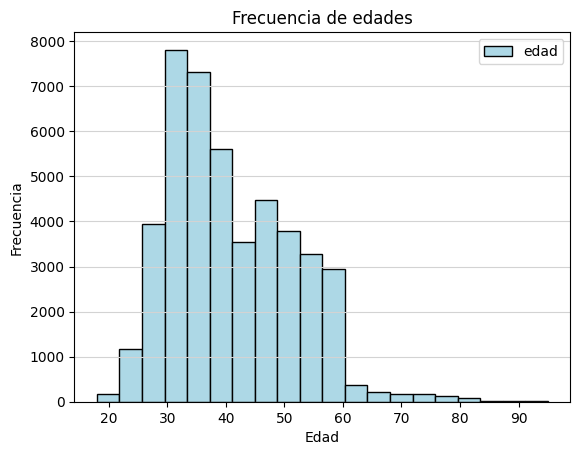

In [12]:
histGra = df01.select("edad").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='lightblue')
plt.ylabel("Frecuencia")
plt.xlabel("Edad")
plt.title(f"Frecuencia de edades")
plt.grid(axis='y', color='lightgray')
plt.show()

#### Comentarios

    - La edad presenta cierta variabilidad en la frecuencia de los datos
        - La mayoría de las personas se concentra entre los 30 y 50 años.
        - Hay pocos individuos en edades muy jóvenes o mayores de 70 años.
        - En general, la población está compuesta principalmente por adultos en edad media, con menor representación en los extremos de 
            edad.

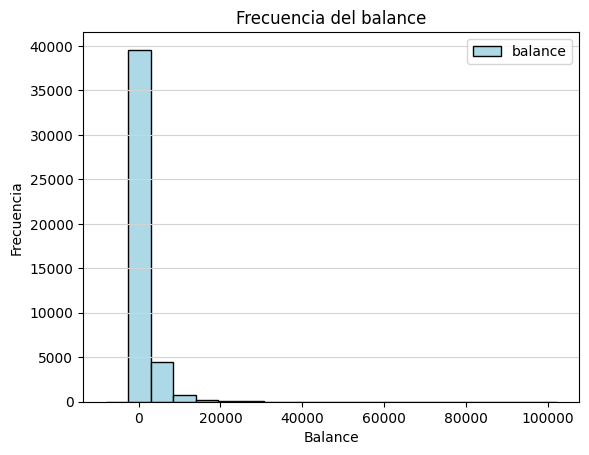

In [13]:
histGra = df01.select("balance").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='lightblue')
plt.ylabel("Frecuencia")
plt.xlabel("Balance")
plt.title(f"Frecuencia del balance")
plt.grid(axis='y', color='lightgray')
plt.show()

#### Comentarios

    - El balance se observa un ruido en la frecuencia de los datos
        - Pocas personas tienen más de 100.000 euros
        - La mayoria de personas tienen menos de 100.000 euros
        - La distribución del balance presenta una alta concentración en valores bajos y una cola larga hacia la derecha, 
            lo que indica asimetría positiva y presencia de valores extremos.
        - La mayoría de las personas mantiene balances relativamente bajos, mientras que solo una minoría concentra valores muy elevados, 
            generando una distribución desigual con fuerte sesgo a la derecha.

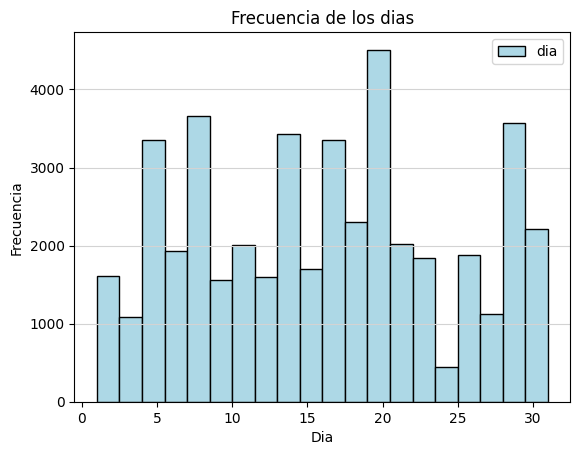

In [14]:
histGra = df01.select("dia").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='lightblue')
plt.ylabel("Frecuencia")
plt.xlabel("Dia")
plt.title(f"Frecuencia de los dias")
plt.grid(axis='y', color='lightgray')
plt.show()

#### Comentarios
    - El día presenta una distribución bastante uniforme con variaciones en la frecuencia
        - No se observa una concentración clara en un rango específico de días.
        - Algunos días muestran picos de frecuencia más altos que otros, pero sin un patrón consistente.
        - En general, los datos se distribuyen a lo largo de todo el mes sin una tendencia dominante clara.
     

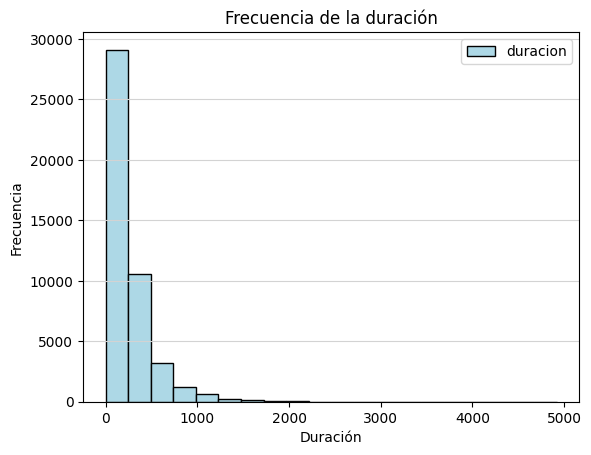

In [15]:
histGra = df01.select("duracion").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='lightblue')
plt.ylabel("Frecuencia")
plt.xlabel("Duración")
plt.title(f"Frecuencia de la duración")
plt.grid(axis='y', color='lightgray')
plt.show()

#### Comentarios
    - La duración presenta una distribución altamente asimétrica con fuerte concentración en valores bajos.
        - La mayoría de las observaciones se concentra en duraciones cortas, principalmente por debajo de los 500.
        - Hay muy pocos datos por encima de los 1500.
        - La distribución de la duración es claramente sesgada a la derecha, indicando que la mayoría de las interacciones son breves, 
            mientras que solo una pequeña proporción presenta tiempos considerablemente más largos.


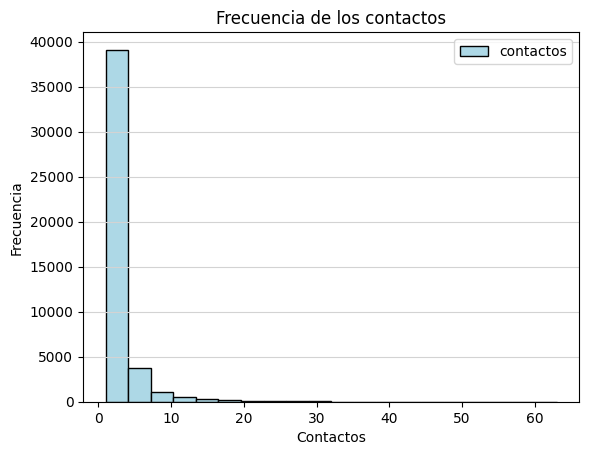

In [16]:
histGra = df01.select("contactos").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='lightblue')
plt.ylabel("Frecuencia")
plt.xlabel("Contactos")
plt.title(f"Frecuencia de los contactos")
plt.grid(axis='y', color='lightgray')
plt.show()

#### Comentarios

    - Los contactos presentan una distribución fuertemente sesgada hacia valores bajos.
        - La mayoría de los casos se concentra en pocos contactos, principalmente entre 1 y 5.
        - Existe una cola larga hacia la derecha, con algunos valores atípicos que alcanzan cifras elevadas (más de 20).
        - La distribución indica que, en general, los clientes son contactados pocas veces, mientras que solo una minoría recibe 
            un número elevado de intentos, generando asimetría positiva.


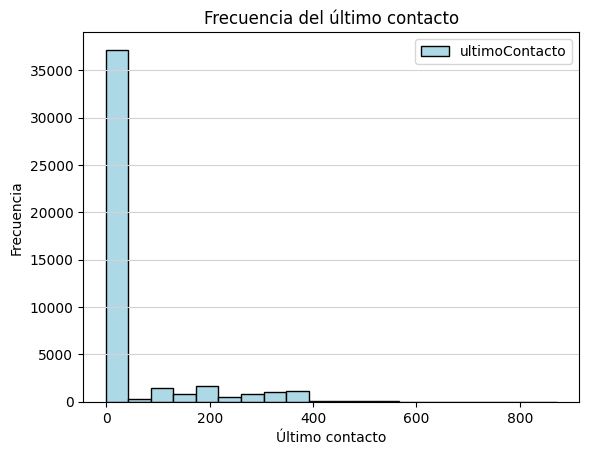

In [17]:
histGra = df01.select("ultimoContacto").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='lightblue')
plt.ylabel("Frecuencia")
plt.xlabel("Último contacto")
plt.title(f"Frecuencia del último contacto")
plt.grid(axis='y', color='lightgray')
plt.show()

#### Comentarios

    - El número de dias desde el último contacto muestra una distribución con fuerte acumulación en valores muy bajos y dispersión en el resto.
        - Se observa una gran concentración de datos en valores cercanos a 0, lo que indica muchos casos sin contacto reciente o 
            con contacto muy cercano.
        - Hay una dispersión amplia en valores más altos, aunque con menor frecuencia.


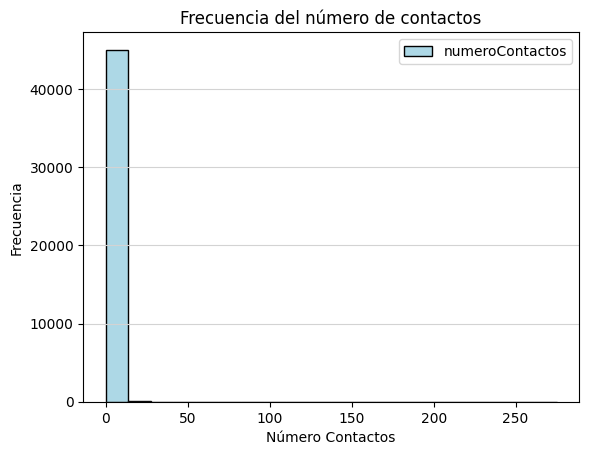

In [18]:
histGra = df01.select("numeroContactos").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='lightblue')
plt.ylabel("Frecuencia")
plt.xlabel("Número Contactos")
plt.title(f"Frecuencia del número de contactos")
plt.grid(axis='y', color='lightgray')
plt.show()

#### Comentarios

    - El número de contactos muestra una concentración en los datos en valores cercanos a 0.
        - Hay una dispersión amplia en valores más altos pero con menor frecuencia.
    

## **Se requiere análizar a fondo las variables numéricas**

    - Se agrupa cada variable numérica y se grafica con el tipo de gráfica BOXPLOT.
    - Las graficas BOXPLOT son una forma de representar gráficamente la distribución de un conjunto de datos, pero 
        de manera más resumida que un histograma. También Ayudan para ver rápidamente cómo se comportan los datos usando 
        algunos valores clave.
        - El boxplot muestra 5 cosas importantes en los datos:
            - Mínimo (esto sin contar los valores atípicos)
            - Primer cuartil o "Q1" el cual nos dice donde están el 25% de nuestros datos.
            - Mediana o "Q2" el cual es el valor central de los datos.
            - Tercer cuartil o "Q3" el cual nos dice donde están el 75% de los datos.
            - Máximo (esto sin contar los valores atípicos)
        - La "caja" de la gráfica va desde el Q1 a Q3, en la cual se encuentran el 50% de los datos, mientras que la linea que se
            encuentra contenida dentro de ella es la que representa la mediana. Es importante recalcar que los puntos que se
            encuentran fuera de los "bigotes" (mínimo y máximo), son los valores atípicos (outliers)


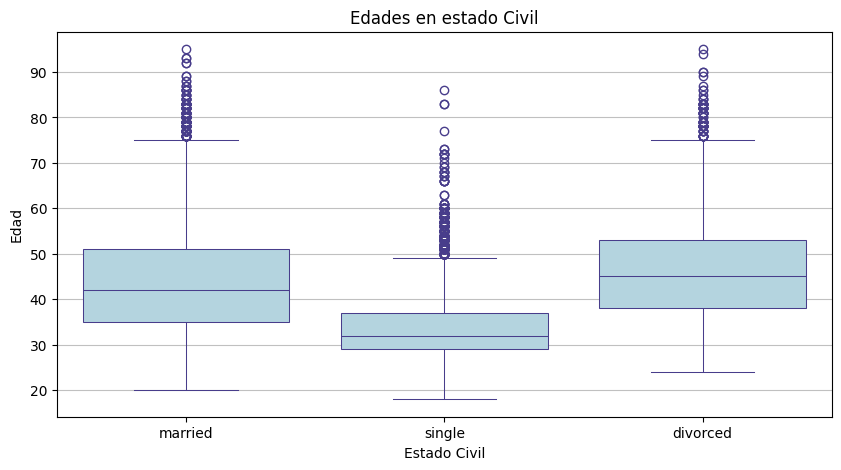

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x='estadoCivil', y="edad", color='lightblue', linecolor='darkslateblue', linewidth=0.75, data=df01.toPandas())
plt.title(f"Edades en estado Civil")
plt.xlabel("Estado Civil")
plt.ylabel("Edad")
plt.grid(axis='y', color='silver')
plt.show()

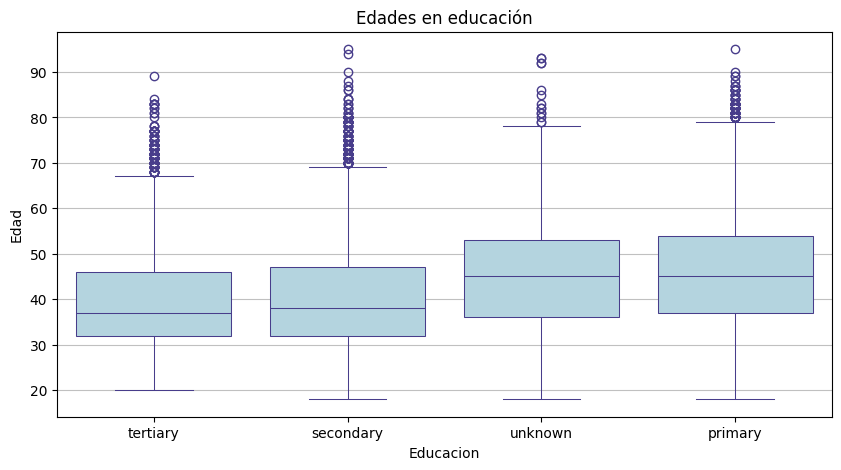

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x='educacion', y="edad", color='lightblue', linecolor='darkslateblue', linewidth=0.75, data=df01.toPandas())
plt.title(f"Edades en educación")
plt.xlabel("Educacion")
plt.ylabel("Edad")
plt.grid(axis='y', color='silver')
plt.show()

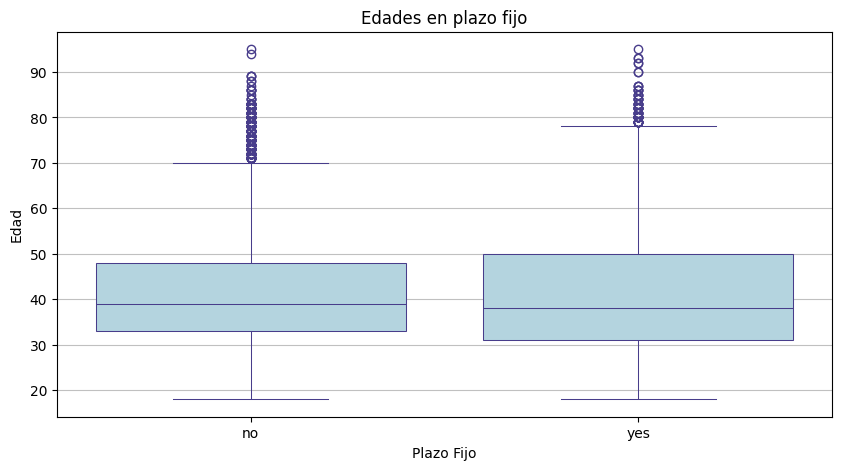

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(x='plazoFijo', y="edad", color='lightblue', linecolor='darkslateblue', linewidth=0.75, data=df01.toPandas())
plt.title(f"Edades en plazo fijo")
plt.xlabel("Plazo Fijo")
plt.ylabel("Edad")
plt.grid(axis='y', color='silver')
plt.show()

#### Comentarios
    -Ambos grupos tienen medianas similares, de aproximadamente 40 años, con IQR entre 30-50.
    -El grupo \"yes\" presenta una caja ligeramente más amplia hacia edades mayores.
    -Outliers presentes en ambos grupos por encima de los 70 años aproximadamente.

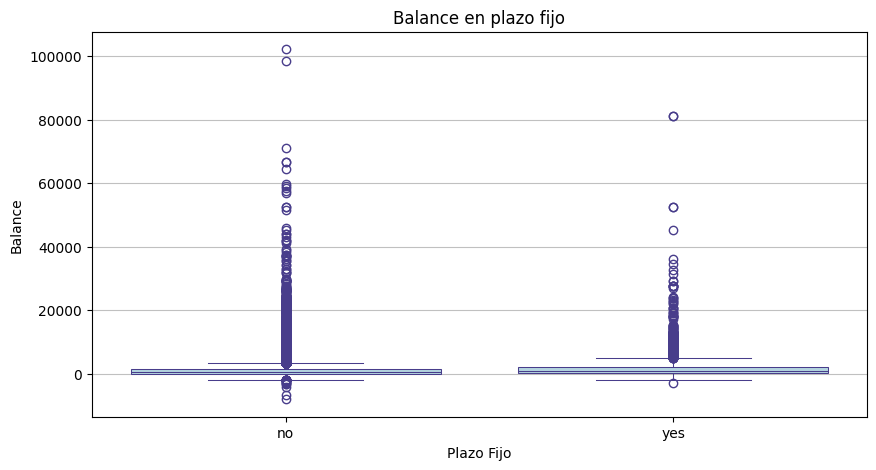

In [22]:
plt.figure(figsize=(10,5))
sns.boxplot(x='plazoFijo', y="balance", color='lightblue', linecolor='darkslateblue', linewidth=0.75, data=df01.toPandas())
plt.title(f"Balance en plazo fijo")
plt.xlabel("Plazo Fijo")
plt.ylabel("Balance")
plt.grid(axis='y', color='silver')
plt.show()

#### Comentarios
    - La mayoría de los clientes tiene saldos bajos sin importar si tienen o no el deposito a plazo fijo.
    - La clase "no" concentra los outliers más altos, ya que llegan a más de 100.000
    - La clase "yes" tiene outliers más moderados

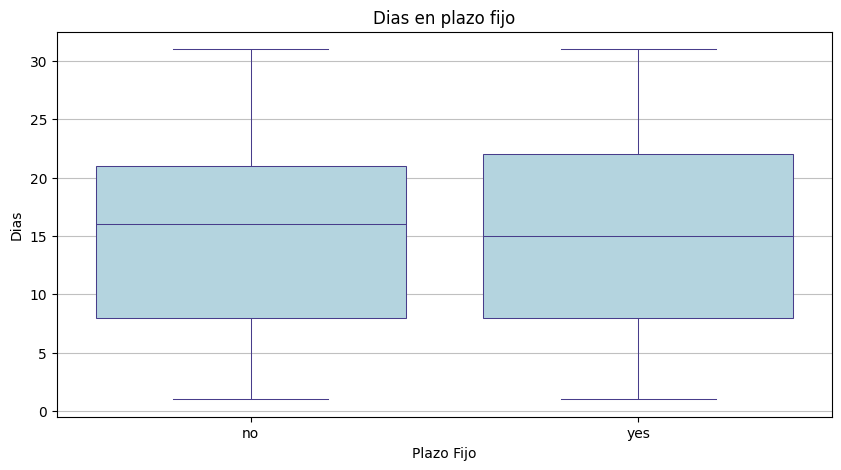

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(x='plazoFijo', y="dia", color='lightblue', linecolor='darkslateblue', linewidth=0.75, data=df01.toPandas())
plt.title(f"Dias en plazo fijo")
plt.xlabel("Plazo Fijo")
plt.ylabel("Dias")
plt.grid(axis='y', color='silver')
plt.show()

#### Comentarios
    - Las distribuciones de ambos grupos son prácticamente idénticas
    - Las medianas alrededor del día 15-16 y rangos similares
    - No se observan diferencias importantes entre ambos

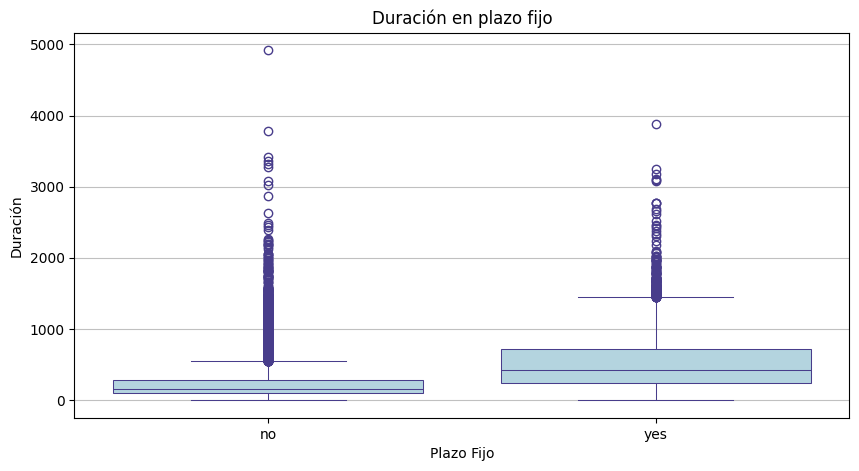

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(x='plazoFijo', y="duracion", color='lightblue', linecolor='darkslateblue', linewidth=0.75, data=df01.toPandas())
plt.title(f"Duración en plazo fijo")
plt.xlabel("Plazo Fijo")
plt.ylabel("Duración")
plt.grid(axis='y', color='silver')
plt.show()

#### Comentarios
    - Diferencia mas marcada en la duracion
    - Grupo "no" tiene la mediana en aproximadamente 180 segundos
    - Grupo "yes" tiene la mediana en aproximadamente 450 segundos
    - Clientes que contrataron el deposito a plazo fijo tuvieron llamadas significativamente más largas

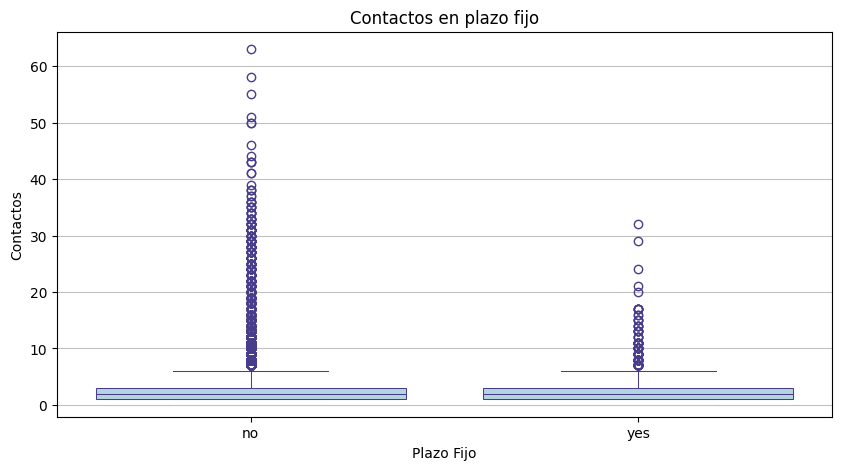

In [25]:
plt.figure(figsize=(10,5))
sns.boxplot(x='plazoFijo', y="contactos", color='lightblue', linecolor='darkslateblue', linewidth=0.75, data=df01.toPandas())
plt.title(f"Contactos en plazo fijo")
plt.xlabel("Plazo Fijo")
plt.ylabel("Contactos")
plt.grid(axis='y', color='silver')
plt.show()

#### Comentarios
    - Ambos grupos tienen medianas de 2 contactos y cajas muy similares
    - La clase "no" concentra outliers mucho más extremos, que van hasta 63 contactos

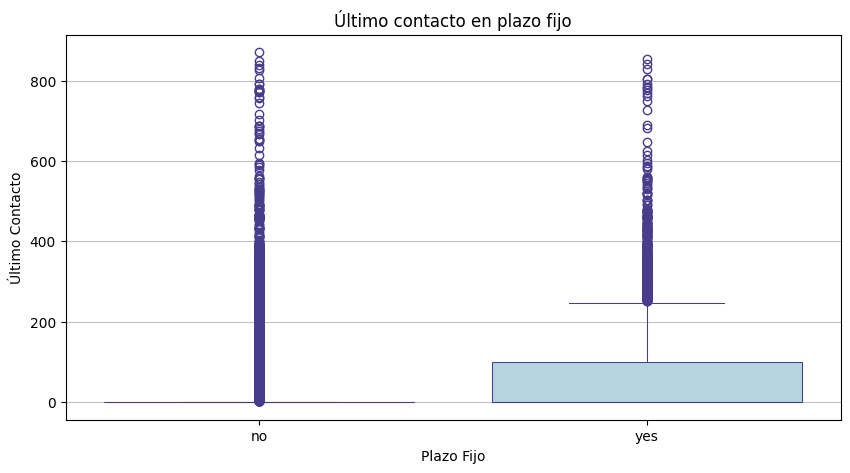

In [26]:
plt.figure(figsize=(10,5))
sns.boxplot(x='plazoFijo', y="ultimoContacto", color='lightblue', linecolor='darkslateblue', linewidth=0.75, data=df01.toPandas())
plt.title(f"Último contacto en plazo fijo")
plt.xlabel("Plazo Fijo")
plt.ylabel("Último Contacto")
plt.grid(axis='y', color='silver')
plt.show()

#### Comentarios
    - El grupo "no" tiene la caja completamente colapsada en -1, que nunca ha contectado
    - "yes" muestra una caja con IQR entre 0 y 250 días
    - Clientes previamente contactados son mas propensos a suscribirse

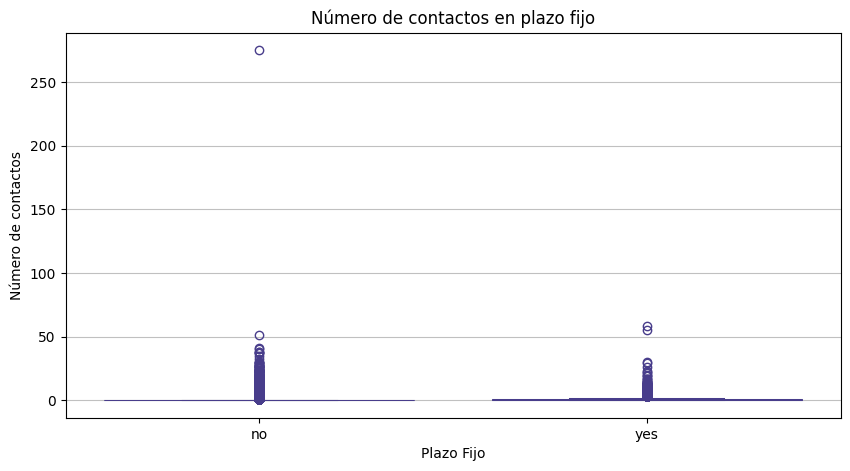

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(x='plazoFijo', y="numeroContactos", color='lightblue', linecolor='darkslateblue', linewidth=0.75, data=df01.toPandas())
plt.title(f"Número de contactos en plazo fijo")
plt.xlabel("Plazo Fijo")
plt.ylabel("Número de contactos")
plt.grid(axis='y', color='silver')
plt.show()

#### Comentarios
    - Ambos grupos tienen medianas en 0 en depositos previos
    - El grupo "no" tiene un outlier extremo, 275 contactos previos
    - El grupo "yes"  tiene un poco de dispersión en la parte alta

### Entendimiento de los datos númericos 
    - Se requiere un objeto auxiliar con solo las columnas numericas:

In [28]:
### Las siguientes columnas se cambian a "INT"
colNum = ['edad', 'balance','dia', 'duracion','contactos','ultimoContacto','numeroContactos']

### Se requiere cambiar la columna "y" de si o no a 1 0
### Además, se requiere incorporarla al dataframe numérico

dfauxNum = df01.select(colNum + ['plazoFijo'])
dfauxNum = dfauxNum.withColumn('plazoFijo', F.when(dfauxNum['plazoFijo'] == 'yes', 1).otherwise(0))
dfauxNum.show(5)

+----+-------+---+--------+---------+--------------+---------------+---------+
|edad|balance|dia|duracion|contactos|ultimoContacto|numeroContactos|plazoFijo|
+----+-------+---+--------+---------+--------------+---------------+---------+
|  58|   2143|  5|     261|        1|            -1|              0|        0|
|  44|     29|  5|     151|        1|            -1|              0|        0|
|  33|      2|  5|      76|        1|            -1|              0|        0|
|  47|   1506|  5|      92|        1|            -1|              0|        0|
|  33|      1|  5|     198|        1|            -1|              0|        0|
+----+-------+---+--------+---------+--------------+---------------+---------+
only showing top 5 rows



In [29]:
### El anterior dataframe auxiliar se convierte en un VectorAssembler de 'feature'

from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation
ensamblador = VectorAssembler(inputCols=dfauxNum.columns, outputCol='features')
### Normalizado y Escalado 
dfNumVector = ensamblador.transform(dfauxNum).select('features')

### Matriz de correlación 
 - permite identificar relaciones lineales entre las variables numéricas.
 - representan correlación negativa fuerte. Valores próximos a 0 sugieren poca relación lineal.
 - Este análisis ayuda a comprender el comportamiento de las variables y detectar posibles redundancias antes del entrenamiento del modelo de clasificación.

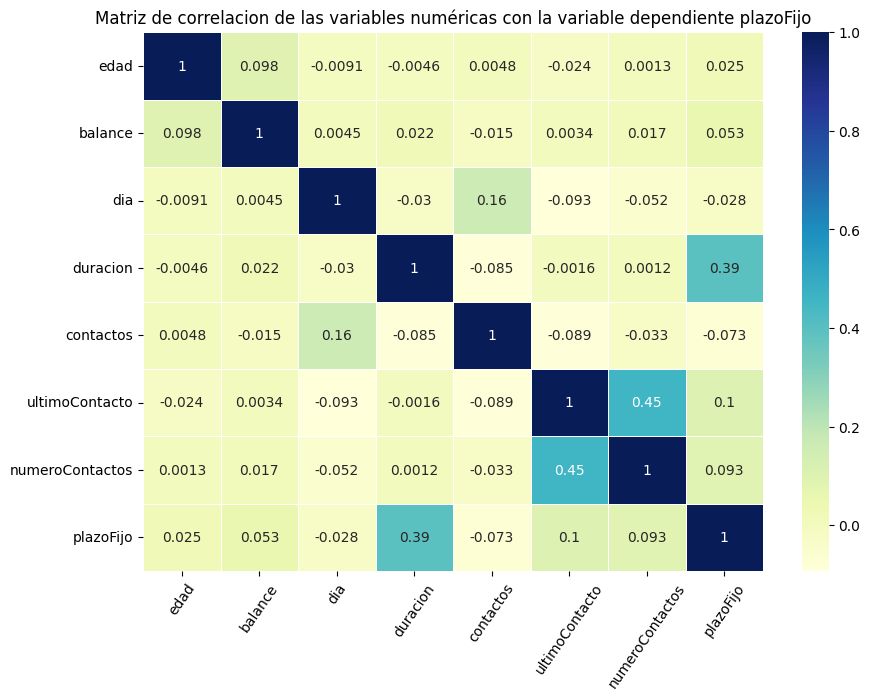

In [30]:
### Se grafica la matriz de correlación: se tiene en cuenta que los datos son ensamblados
matrizCorr = Correlation.corr(dfNumVector, 'features').head()

## Se procede a pintar la matriz de correlación
vectorCorr = matrizCorr[0].toArray()

#Se crea un objeto dataframe con el arreglo anterior de Correlación de Pearson
dfCorrelation = pd.DataFrame(vectorCorr, columns=dfauxNum.columns, index=dfauxNum.columns)

plt.figure(figsize=(10,7))
sns.heatmap(dfCorrelation, 
            annot=True, 
            cmap='YlGnBu', 
            linewidths=0.5)
plt.title("Matriz de correlacion de las variables numéricas con la variable dependiente plazoFijo")
plt.xticks(rotation=55)
plt.yticks(rotation=0)
plt.show()


#### Comentarios generales
### Notas:
    - Los coeficientes próximos a 1 reflejan una relación positiva fuerte entre variables.
    - Los valores cercanos a -1 indican una relación negativa significativa.
    - Cuando la correlación se aproxima a 0, la relación lineal entre las variables es débil o inexistente.


- En este conjunto de datos no se observan problemas importantes de multicolinealidad entre las variables independientes.
- La asociación más destacada corresponde a las variables pdays y previous, con una correlación de 0.45.
  - Esto sugiere que, si un cliente ha sido contactado anteriormente (previous),
  - es más probable que exista un registro del número de días transcurridos desde el último contacto (pdays).
- La correlación entre edad y balance es baja, aproximadamente de 0.10.
- Esto indica que el saldo de la cuenta no presenta una dependencia significativa respecto a la edad de los clientes dentro de este dataset.
- En el resto de variables, las correlaciones son muy reducidas y cercanas a cero.

En conclusión, la matriz de correlación muestra que las variables numéricas presentan, en general, relaciones débiles entre sí. La única relación moderada identificada es la existente entre pdays y previous. Esto permite inferir que el dataset no presenta redundancia considerable entre variables, por lo que cada una contribuye con información distinta y útil para el análisis y la interpretación de los resultados.


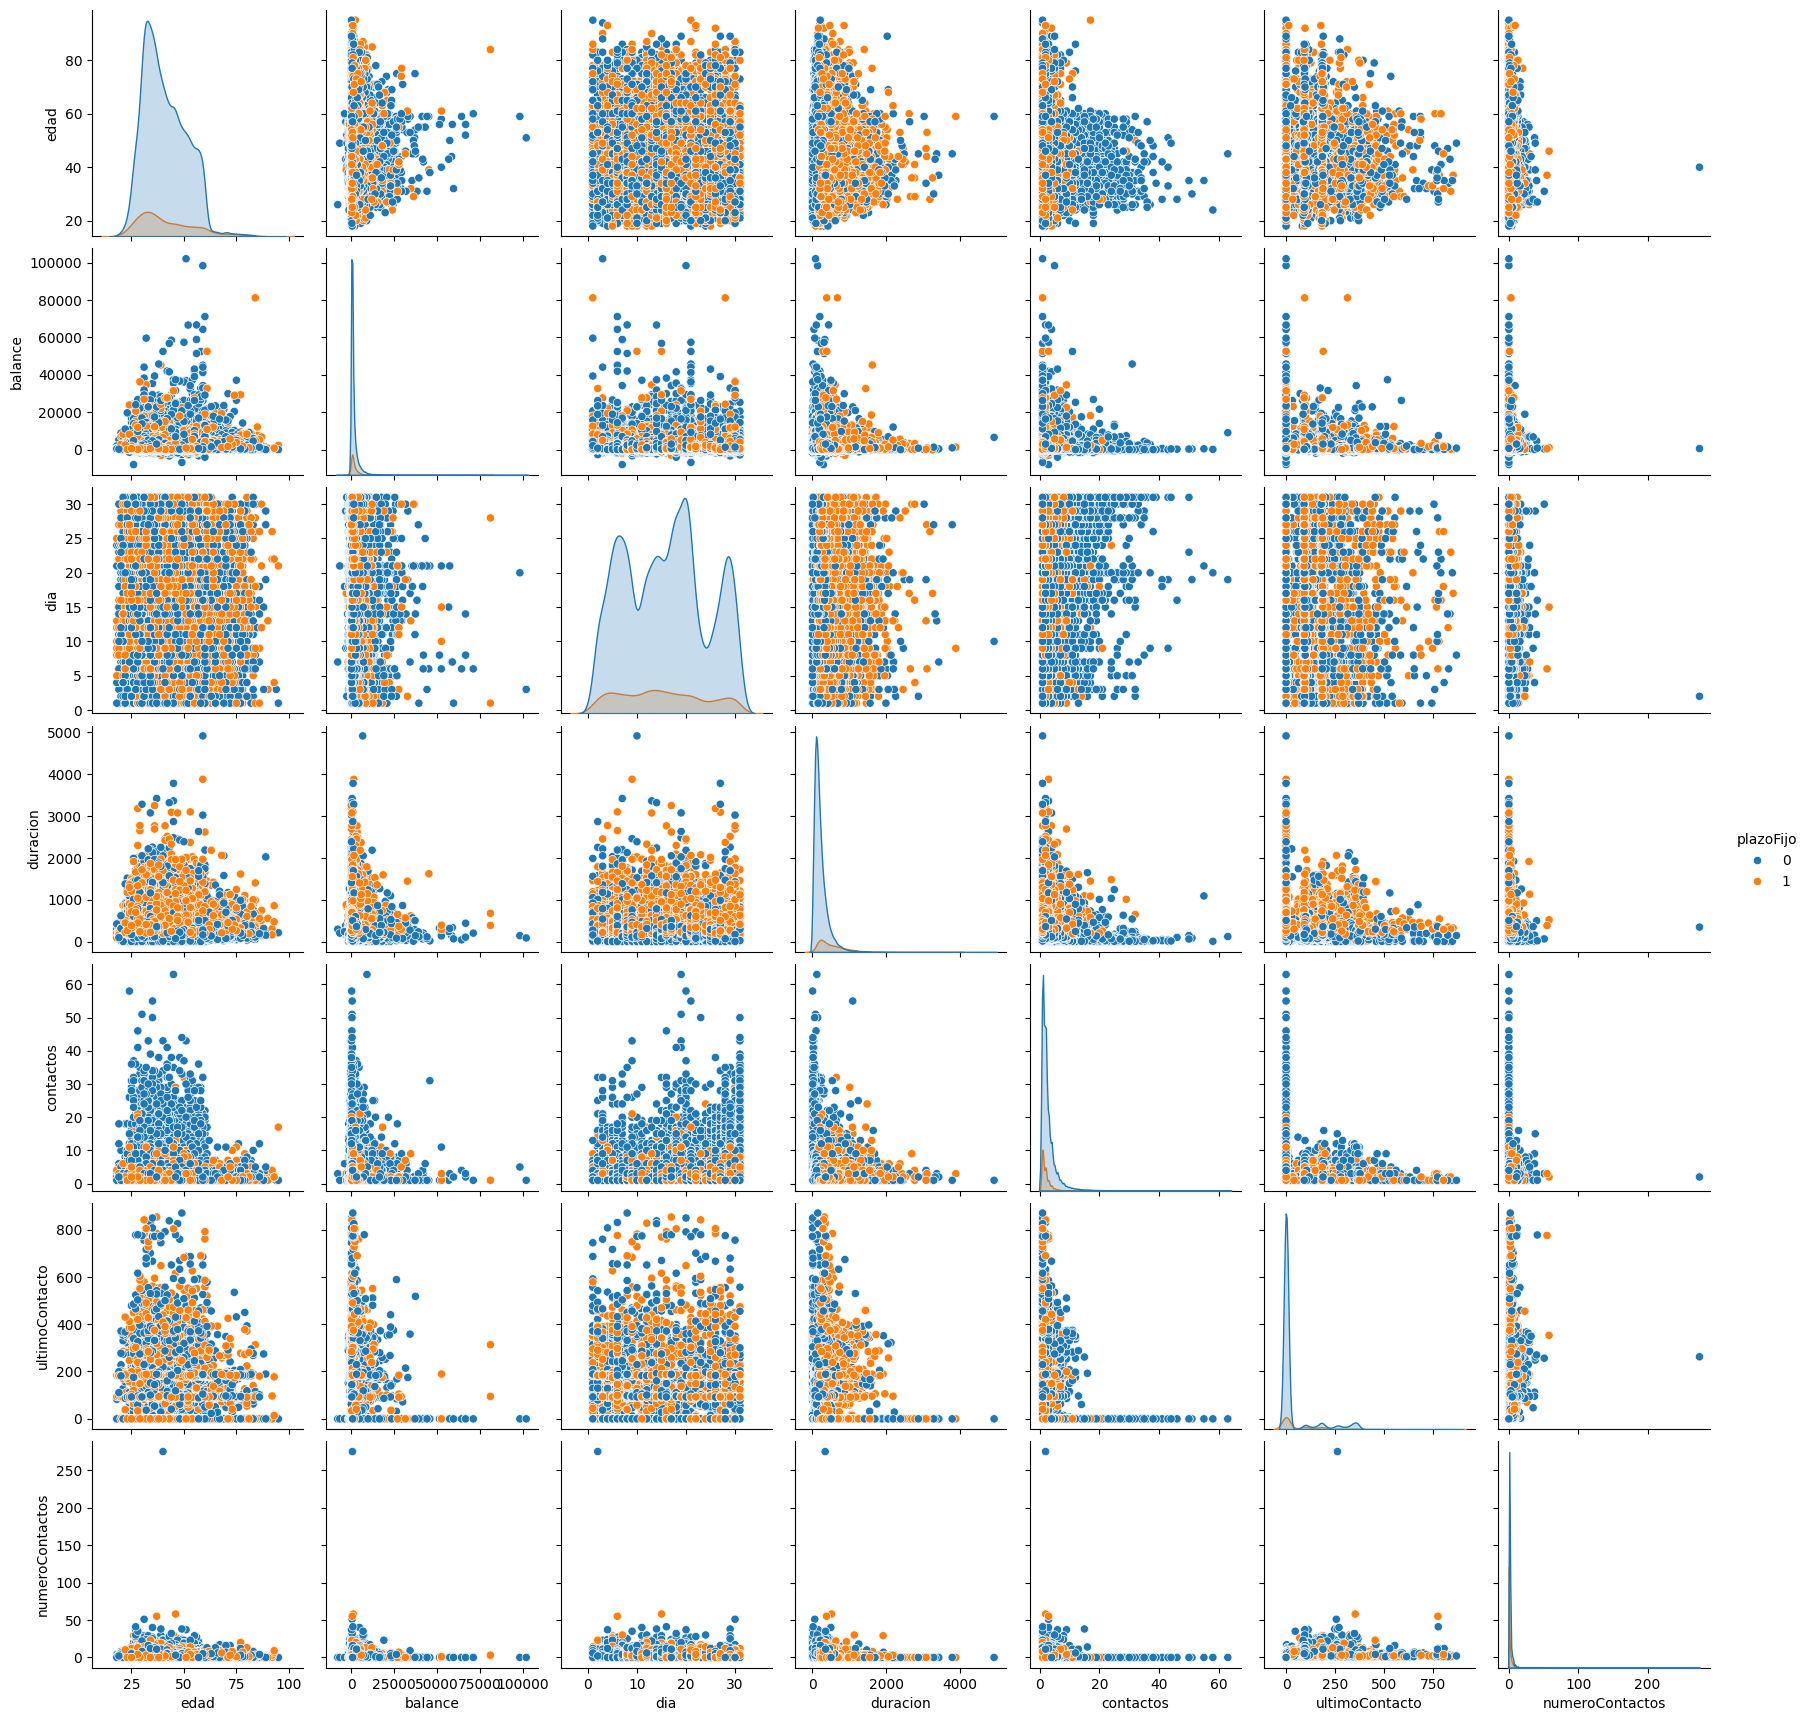

In [31]:
### Se requiere hacer un grafico 
sns.pairplot(dfauxNum.toPandas(), kind = 'scatter', hue='plazoFijo')
plt.show()

### Interpretación del pairplot (matriz de dispersión)
El pairplot permite analizar de forma conjunta:
- La distribución individual de cada variable mediante histogramas o curvas KDE.
- La separación entre clases según el color:
  - Azul: clientes que no se suscribieron.
  - Naranja: clientes que sí se suscribieron.

### Análisis

- **ultimoContacto** presenta una fuerte concentración en el valor 0, indicando que la mayoría de los clientes nunca había sido contactada previamente. Al relacionar esta variable con duracion, se observa que los clientes que sí se suscribieron suelen aparecer en combinaciones de llamadas largas y valores positivos de ultimoContacto. Esto sugiere que el contacto previo, junto con una interacción telefónica extensa, aumenta la probabilidad de conversión.
- **NumeroContactos** muestra una distribución altamente concentrada cerca de 0. Además, aparece un valor atípico cercano a 275 contactos, posiblemente asociado a un error de registro, por lo que sería recomendable tratarlo o eliminarlo antes del modelado. En términos visuales, esta variable no evidencia una diferenciación clara entre las clases
- **Duracion** es la variable con mayor capacidad de discriminación dentro del pairplot. En la diagonal KDE se aprecia que la clase “no” se concentra en llamadas cortas, mientras que la clase “yes” presenta una distribución desplazada hacia duraciones más altas, principalmente entre 500 y 1500 segundos. Este comportamiento se mantiene de forma consistente en los gráficos de dispersión frente a las demás variables, lo que refuerza su relevancia predictiva
- **Contactos** evidencia una relación inversa con la conversión. Los clientes suscritos se concentran principalmente entre 1 y 5 contactos, mientras que a partir de valores más altos predominan los clientes que no se suscribieron. Esto indica que insistir excesivamente durante la campaña reduce la efectividad de conversión.
- **Edad** presenta una ligera diferencia entre clases. La distribución de clientes suscritos muestra una mayor presencia relativa en edades superiores a 55 años, lo que coincide con el patrón observado previamente en clientes jubilados.
- **Balance** contiene los valores atípicos más extremos, pertenecientes mayoritariamente a la clase “no”. Esto indica que un saldo elevado no implica necesariamente una mayor probabilidad de suscripción.
- **Día** resulta ser la variable menos informativa. Aunque su distribución presenta un comportamiento bimodal, este patrón es prácticamente igual en ambas clases y no se identifican tendencias temporales relevantes en los gráficos de dispersión.

### Conclusión

El pairplot evidencia que Duracion es la variable más influyente para distinguir entre clientes suscritos y no suscritos. También se identifican patrones útiles en variables como ultimoContacto y Contacto, mientras que variables como Día o Balance aportan poca separación visual entre clases. Asimismo, el análisis permite detectar valores atípicos relevantes que deberían considerarse durante la etapa de preprocesamiento del modelo.


### Gráfico de torta para las variables "Yes" / "No"

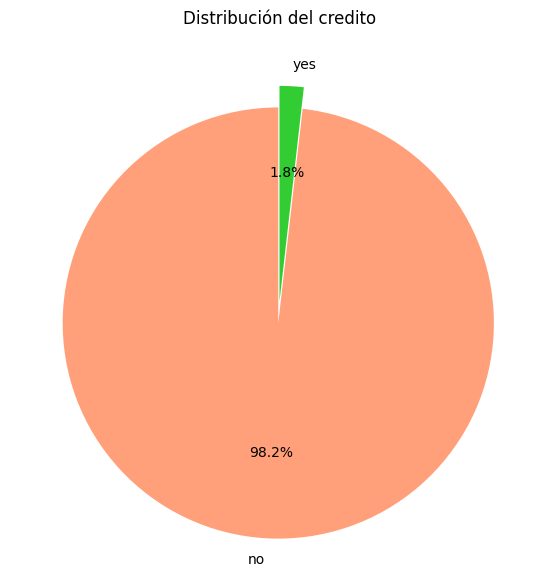

In [32]:
#### Se requiere pintar ['credito', 'hipoteca', 'prestamo'] por separado
explode = (0.1 , 0)
colors = ['lightsalmon', 'limegreen']

plt.figure(figsize=(7,7))
cantBin =df01.groupBy('credito').count().toPandas()
cantBin.set_index('credito')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Distribución del credito')
plt.ylabel('')
plt.show()

### Distribución altamente desbalanceada

* La categoría “no” representa aproximadamente el 98.2% de los clientes, indicando que la gran mayoría no posee créditos en incumplimiento.
* Por otro lado, la categoría “yes” corresponde únicamente al 1.8% de los registros, reflejando una presencia muy reducida de clientes con mora.
* Este comportamiento evidencia un desbalance extremadamente marcado entre clases, siendo una de las variables categóricas con menor representación de la clase positiva dentro del dataset.
* Debido a esta diferencia tan amplia, la variable podría generar sesgos en algunos modelos predictivos, por lo que sería recomendable considerar técnicas de balanceo o métricas adecuadas durante la etapa de modelado.


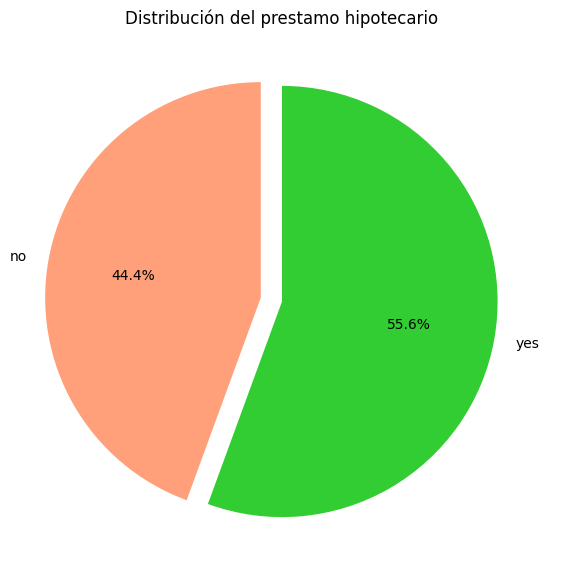

In [33]:
explode = (0.1 , 0)
colors = ['lightsalmon', 'limegreen']

plt.figure(figsize=(7,7))
cantBin =df01.groupBy('hipoteca').count().toPandas()
cantBin.set_index('hipoteca')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Distribución del prestamo hipotecario')
plt.ylabel('')
plt.show()
plt.show()

### Distribución relativamente equilibrada entre categorías
- La categoría “yes” representa el 55.6% de los clientes, lo que indica que más de la mitad posee un préstamo hipotecario activo.
- La categoría “no” corresponde al 44.4%, reflejando una distribución bastante cercana entre ambos grupos.
- En comparación con las demás variables binarias analizadas, esta es la que presenta el balance más uniforme entre categorías.
- Desde una perspectiva financiera, los clientes con hipoteca vigente podrían disponer de menor capacidad de endeudamiento o liquidez, lo que podría influir en su decisión frente a nuevos productos financieros.


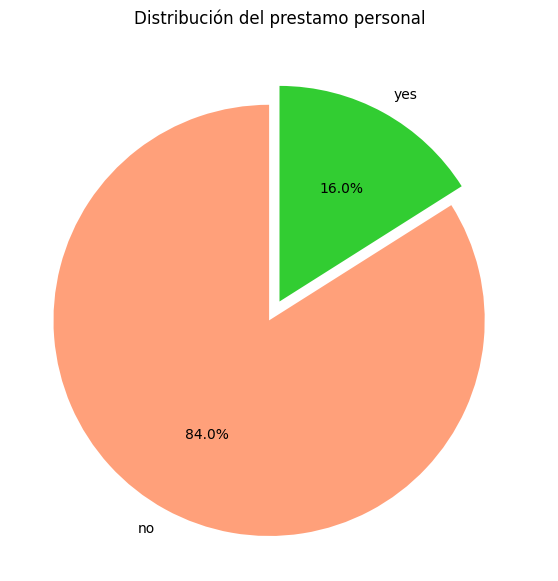

In [34]:
explode = (0.1 , 0)
colors = ['lightsalmon', 'limegreen']

plt.figure(figsize=(7,7))
cantBin =df01.groupBy('prestamo').count().toPandas()
cantBin.set_index('prestamo')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Distribución del prestamo personal')
plt.ylabel('')
plt.show()
plt.show()

### Distribución desbalanceada

- La categoría “no” concentra aproximadamente el 84.0% de los clientes, indicando que la mayoría no posee préstamos personales activos.
- La categoría “yes” representa cerca del 16.0%, mostrando una participación considerablemente menor dentro del conjunto de datos.
- Aunque el desbalance no es tan extremo como el observado en la variable de créditos en incumplimiento, sigue existiendo una diferencia importante entre ambas categorías.
- Desde el punto de vista financiero, los clientes con préstamos personales vigentes podrían tener una menor disposición a adquirir nuevos productos bancarios debido a sus compromisos económicos actuales.


### Variables categóricas multidimensionales
- Estas gráficas de barras representan la frecuencia absoluta de las distintas categorías presentes en las variables categóricas del dataset.
- Su análisis permite identificar:
  - Categorías predominantes que podrían generar sesgos durante el entrenamiento del modelo.
  - Categorías con muy baja representación, las cuales podrían aportar poca información estadística o afectar la generalización.
  - Registros con valores “unknown”, que requieren un tratamiento específico, como imputación, agrupación o análisis adicional antes del modelado.
- Este tipo de visualización facilita comprender la distribución de los datos categóricos y detectar posibles problemas de calidad o desbalance en el conjunto de datos.


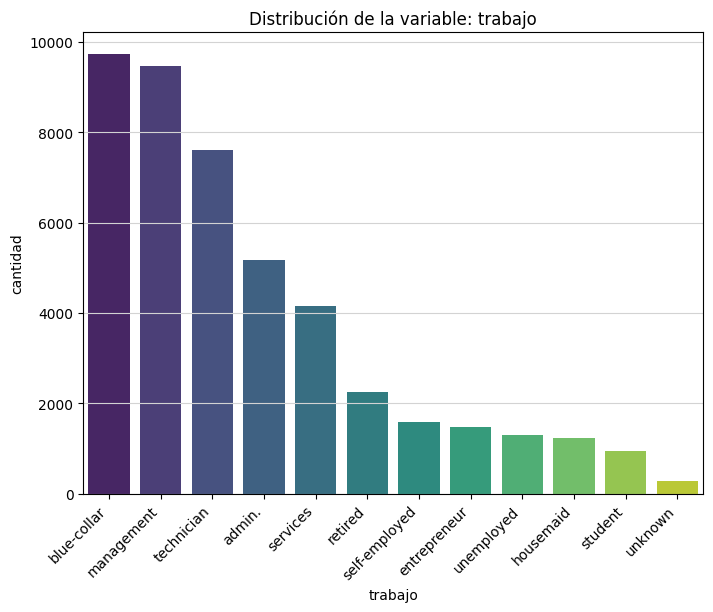

In [35]:
## Las variables son: ['trabajo','estadoCivil','educacion','credito','hipoteca','prestamo','medioComunicacion','mes','resultadoMarketing','plazoFijo']
cantMulti =df01.groupBy('trabajo').count().toPandas()
### Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(data=cantMulti, x='trabajo', y='count',palette='viridis',hue='trabajo', legend=False)
plt.xlabel('trabajo')
plt.ylabel('cantidad')
plt.title(f'Distribución de la variable: trabajo')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', color='lightgray')
plt.show()

### Comentarios
- Las categorías con mayor frecuencia corresponden a:
  - blue-collar (trabajadores manuales), con aproximadamente 9,800 registros.
  - management (cargos directivos o administrativos), con cerca de 9,700 registros.
  - technician (técnicos), con alrededor de 7,700 registros.
- En contraste, las categorías menos representadas son:
  - student, con cerca de 900 registros.
  - unknown, con aproximadamente 300 registros.
- La presencia de la categoría “unknown” requiere un tratamiento específico durante el preprocesamiento, ya sea mediante imputación, agrupación con otras categorías o manteniéndola como una categoría independiente.

- En general, la variable presenta una alta diversidad de perfiles ocupacionales, lo que puede aportar información relevante para segmentar el comportamiento de los clientes y mejorar la capacidad predictiva del modelo.


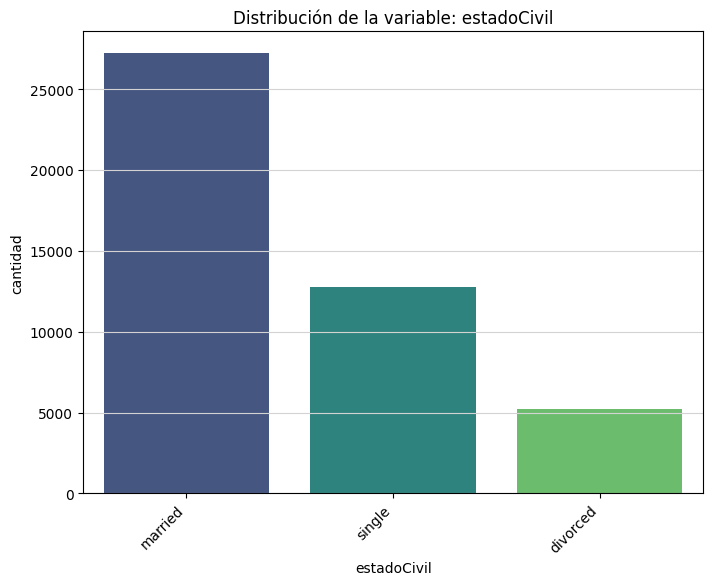

In [36]:
## Las variables son: []
cantMulti =df01.groupBy('estadoCivil').count().toPandas()
### Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(data=cantMulti, x='estadoCivil', y='count',palette='viridis',hue='estadoCivil', legend=False)
plt.xlabel('estadoCivil')
plt.ylabel('cantidad')
plt.title(f'Distribución de la variable: estadoCivil')
plt.xticks(rotation=45,ha='right')
plt.grid(axis='y', color='lightgray')
plt.show()

- La distribución de esta variable es claramente desbalanceada entre las distintas categorías:
  - married (casados) concentra aproximadamente 27,000 registros.
  - single (solteros) reúne cerca de 13,000 registros.
  - divorced (divorciados) representa alrededor de 5,300 clientes.
- La fuerte predominancia de clientes casados podría generar un sesgo del modelo hacia este perfil, debido a su mayor representación dentro del dataset.
- A diferencia de otras variables categóricas, en este caso no se observan registros con valores “unknown”, lo que facilita el proceso de limpieza y preparación de datos.
- Desde una perspectiva financiera, los clientes solteros podrían presentar mayor liquidez o flexibilidad económica, lo que potencialmente los hace más receptivos a productos de inversión o depósitos.


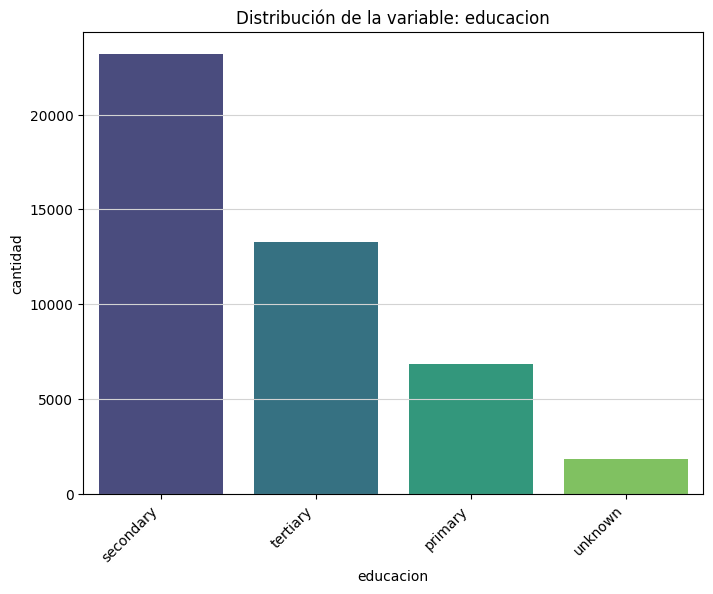

In [37]:
## Las variables son: []
cantMulti =df01.groupBy('educacion').count().toPandas()
### Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(data=cantMulti, x='educacion', y='count',palette='viridis',hue='educacion', legend=False)
plt.xlabel('educacion')
plt.ylabel('cantidad')
plt.title(f'Distribución de la variable: educacion')
plt.xticks(rotation=45,ha='right')
plt.grid(axis='y', color='lightgray')
plt.show()

- La variable presenta cuatro niveles educativos con una distribución claramente desbalanceada:
  - secondary (educación secundaria) es la categoría predominante, con aproximadamente 23,000 registros.
  - tertiary (educación universitaria o superior) cuenta con cerca de 13,000 clientes.
  - primary (educación básica) representa alrededor de 6,700 registros.
  - unknown incluye aproximadamente 1,800 casos sin información educativa registrada.
- El predominio de la educación secundaria indica que gran parte de los clientes pertenece a un nivel educativo intermedio dentro del dataset.
- Los clientes con educación terciaria suelen asociarse con mayores niveles de ingreso y una mayor probabilidad de adquirir productos financieros relacionados con ahorro o inversión.
- La categoría “unknown” requiere un tratamiento previo al modelado, ya sea mediante imputación, agrupación o manejo específico, para evitar posibles sesgos o pérdida de información en el análisis.


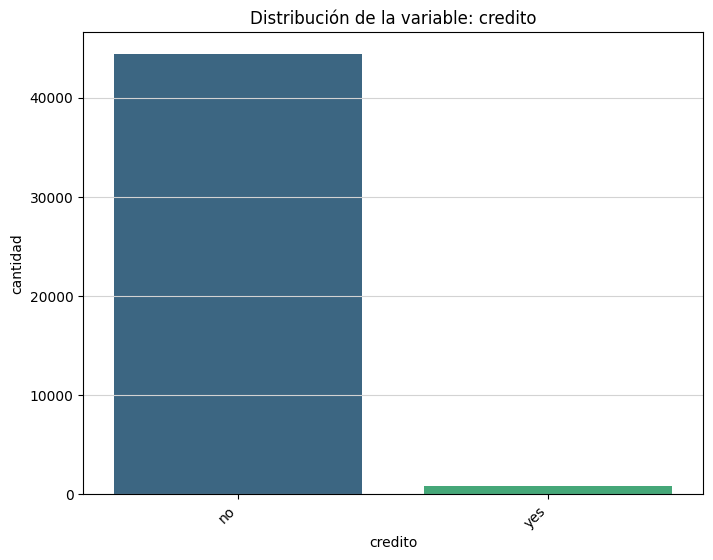

In [38]:
## Las variables son: []
cantMulti =df01.groupBy('credito').count().toPandas()
### Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(data=cantMulti, x='credito', y='count',palette='viridis',hue='credito', legend=False)
plt.xlabel('credito')
plt.ylabel('cantidad')
plt.title(f'Distribución de la variable: credito')
plt.xticks(rotation=45,ha='right')
plt.grid(axis='y', color='lightgray')
plt.show()

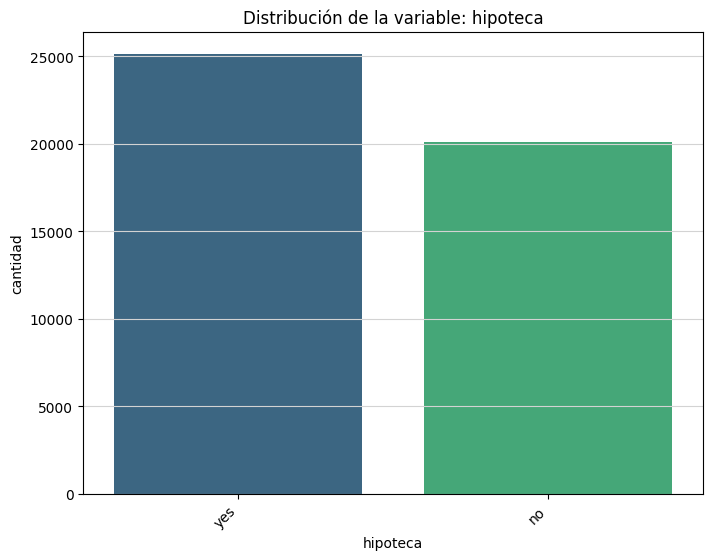

In [39]:
## Las variables son: []
cantMulti =df01.groupBy('hipoteca').count().toPandas()
### Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(data=cantMulti, x='hipoteca', y='count',palette='viridis',hue='hipoteca', legend=False)
plt.xlabel('hipoteca')
plt.ylabel('cantidad')
plt.title(f'Distribución de la variable: hipoteca')
plt.xticks(rotation=45,ha='right')
plt.grid(axis='y', color='lightgray')
plt.show()

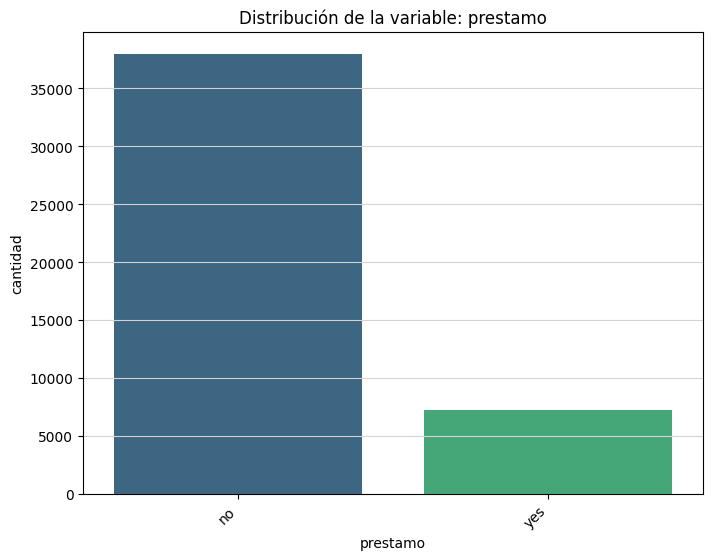

In [40]:
## Las variables son: []
cantMulti =df01.groupBy('prestamo').count().toPandas()
### Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(data=cantMulti, x='prestamo', y='count',palette='viridis',hue='prestamo', legend=False)
plt.xlabel('prestamo')
plt.ylabel('cantidad')
plt.title(f'Distribución de la variable: prestamo')
plt.xticks(rotation=45,ha='right')
plt.grid(axis='y', color='lightgray')
plt.show()

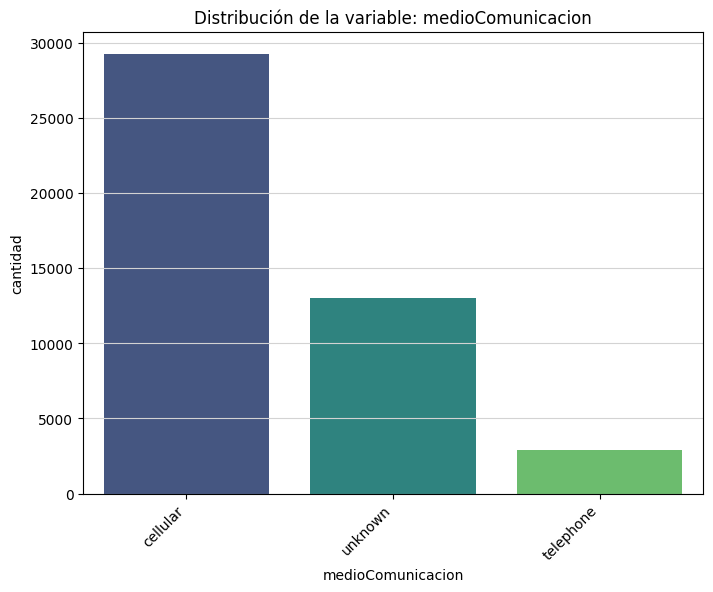

In [41]:
## Las variables son: []
cantMulti =df01.groupBy('medioComunicacion').count().toPandas()
### Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(data=cantMulti, x='medioComunicacion', y='count',palette='viridis',hue='medioComunicacion', legend=False)
plt.xlabel('medioComunicacion')
plt.ylabel('cantidad')
plt.title(f'Distribución de la variable: medioComunicacion')
plt.xticks(rotation=45,ha='right')
plt.grid(axis='y', color='lightgray')
plt.show()

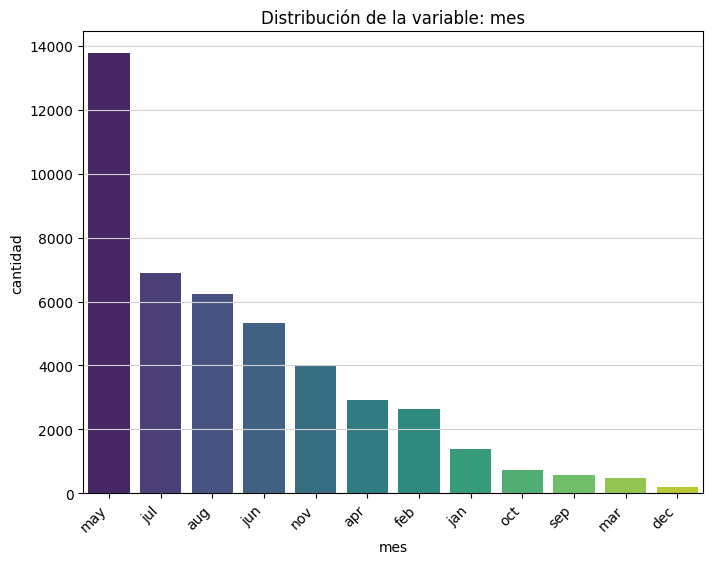

In [42]:
## Las variables son: []
cantMulti =df01.groupBy('mes').count().toPandas()
### Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(data=cantMulti, x='mes', y='count',palette='viridis',hue='mes', legend=False)
plt.xlabel('mes')
plt.ylabel('cantidad')
plt.title(f'Distribución de la variable: mes')
plt.xticks(rotation=45,ha='right')
plt.grid(axis='y', color='lightgray')
plt.show()

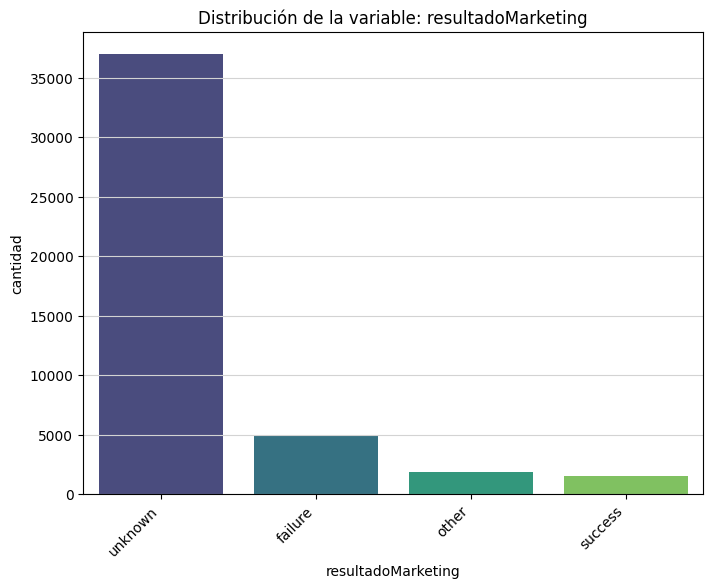

In [43]:
## Las variables son: []
cantMulti =df01.groupBy('resultadoMarketing').count().toPandas()
### Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(data=cantMulti, x='resultadoMarketing', y='count',palette='viridis',hue='resultadoMarketing', legend=False)
plt.xlabel('resultadoMarketing')
plt.ylabel('cantidad')
plt.title(f'Distribución de la variable: resultadoMarketing')
plt.xticks(rotation=45,ha='right')
plt.grid(axis='y', color='lightgray')
plt.show()

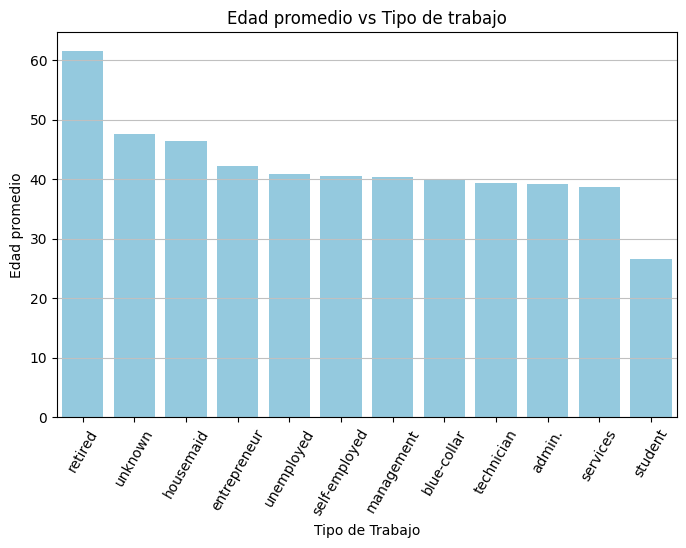

In [44]:
monto = df01.groupBy('trabajo').agg({'edad':'mean'}).toPandas()
monto = monto.sort_values('avg(edad)',ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=monto, x='trabajo', y='avg(edad)', color='skyblue')
plt.xlabel('Tipo de Trabajo')
plt.ylabel('Edad promedio')
plt.title('Edad promedio vs Tipo de trabajo')
plt.xticks(rotation=60)
plt.grid(axis='y', color='silver')
plt.show()

In [45]:
## Lista de los nombres de las variables
NomCol =['edad','trabajo','estadoCivil','educacion','credito','balance','hipoteca','prestamo','medioComunicacion','dia','mes','duracion','contactos','ultimoContacto','numeroContactos','resultadoMarketing','plazoFijo']
### Las siguientes columnas son Numéricas
colNum = ['edad', 'balance','dia', 'duracion','contactos','ultimoContacto','numeroContactos']

### Se requiere graficar la relación del balance (monto promedio anual) por categoria de Job (tipo de trabajo)
monto_trabajo = df01.groupBy('trabajo').agg({'balance':'mean'}).toPandas()
### El promedio sobre el monto y el tipo de trabajo: Se ordena de mayor a menor por monto

### contacto

- Se identifican tres canales principales de comunicación con los clientes:
  - cellular (teléfono móvil), que representa la mayor cantidad de registros con aproximadamente 29,000 casos.
  - unknown (canal no registrado), con cerca de 13,000 registros.
  - telephone (teléfono fijo), con alrededor de 3,000 registros.
- La elevada proporción de valores en “unknown” indica que en una parte importante del dataset no se conoce el medio de contacto utilizado. Esto representa una limitación relevante y debería revisarse antes del modelado, ya que puede afectar la calidad de las predicciones.
- El canal de comunicación puede influir directamente en la efectividad de la campaña, debido a que los contactos realizados por teléfono móvil suelen presentar mayores tasas de respuesta y conversión en comparación con otros medios.
  
### Resultado de la campaña de marketing anterior

- La variable relacionada con el resultado de campañas previas presenta la siguiente distribución:
  - unknown (sin campaña previa registrada), con aproximadamente 37,000 registros.
  - failure (campaña anterior fallida), con cerca de 4,900 casos.
  - other (resultado no clasificado), con alrededor de 1,800 registros.
  - success (campaña anterior exitosa), con aproximadamente 1,500 clientes.
- La alta presencia de la categoría “unknown” está relacionada con los valores observados en la variable "ultimoContacto", donde muchos registros se concentran en valores cercanos a -1 o 0, indicando ausencia de contactos previos.
- Aunque la categoría “success” tiene una representación reducida dentro del dataset, es una de las más relevantes desde el punto de vista predictivo, ya que los clientes con campañas exitosas anteriores presentan una probabilidad considerablemente mayor de suscribirse nuevamente.


### Análisis por rangos de edad

In [46]:
# Agrupar edad en rangos
dfEdad = df01.toPandas()
dfEdad['Rango_Edad'] = pd.cut(
    dfEdad['edad'],
    bins=[17, 30, 40, 50, 60, 70, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '61-70', 'Más de 70']
)

# distribución por rango de edad
tablaEdad = dfEdad.groupby('Rango_Edad', observed=False).agg(
    Total_Clientes=('Rango_Edad', 'count'),
    Clientes_Yes=('plazoFijo', lambda x: (x == 'yes').sum()),
    Clientes_No=('plazoFijo', lambda x: (x == 'no').sum())
).reset_index()

#Calcular porcentajes
tablaEdad['Porcentaje_Total'] = (tablaEdad['Total_Clientes'] / tablaEdad['Total_Clientes'].sum()) * 100
tablaEdad['Tasa_Conversion_%'] = (tablaEdad['Clientes_Yes'] / tablaEdad['Total_Clientes']) * 100

# Mostrar tabla
tablaEdad

,Rango_Edad,Total_Clientes,Clientes_Yes,Clientes_No,Porcentaje_Total,Tasa_Conversion_%
0,18-30,7030,1145,5885,15.549313,16.287340
1,31-40,17687,1812,15875,39.121010,10.244813
2,41-50,11239,1019,10220,24.858994,9.066643
3,51-60,8067,811,7256,17.843003,10.053304
4,61-70,701,284,417,1.550508,40.513552
5,Más de 70,487,218,269,1.077171,44.763860


### Comentarios generales
- Los rangos intermedios de edad (31-40, 41-50 y 51-60 años) presentan las tasas de conversión más bajas dentro del conjunto analizado, todas por debajo del 11%. Esto sugiere que los clientes en plena etapa laboral, con mayores responsabilidades financieras como hipotecas, préstamos o gastos familiares, tienden a ser menos receptivos a la contratación de depósitos a plazo.
- El grupo de 18-30 años muestra una tasa de conversión ligeramente superior (alrededor del 16%), lo que puede asociarse a una menor carga financiera y mayor flexibilidad económica en esta etapa inicial de la vida laboral.
- Los clientes entre 61-70 años alcanzan una tasa de conversión del 40,6%, mientras que los mayores de 70 años presentan la tasa más alta, cercana al 45%, consolidándose como el grupo con mayor propensión a suscribir el producto.
- Este comportamiento puede explicarse desde una perspectiva financiera: las personas en etapa de jubilación o prejubilación suelen contar con menor nivel de deuda, mayor ahorro acumulado y una preferencia por productos de bajo riesgo que generen estabilidad en sus ingresos, como los depósitos a plazo.
- En conjunto, se observa que la edad es un factor determinante en la propensión a la suscripción, con una relación no lineal donde los extremos (jóvenes y adultos mayores) muestran mayor respuesta que los grupos de edad intermedia.


# **Calidad de los datos**
    Verificación la cantidad de datos nulos

In [47]:
# Se itera sobre todas las columnas del DataFrame df02 para contar cuántos valores nulos tiene cada una
# los algoritmos de Spark MLlib no toleran valores nulos en las columnas de entrada
for columna in df01.columns:
    cantNulos = df01.where(F.col(columna).isNull()).count()
    print(f"'{columna}' : {cantNulos} valores nulos")

'edad' : 0 valores nulos
'trabajo' : 0 valores nulos
'estadoCivil' : 0 valores nulos
'educacion' : 0 valores nulos
'credito' : 0 valores nulos
'balance' : 0 valores nulos
'hipoteca' : 0 valores nulos
'prestamo' : 0 valores nulos
'medioComunicacion' : 0 valores nulos
'dia' : 0 valores nulos
'mes' : 0 valores nulos
'duracion' : 0 valores nulos
'contactos' : 0 valores nulos
'ultimoContacto' : 0 valores nulos
'numeroContactos' : 0 valores nulos
'resultadoMarketing' : 0 valores nulos
'plazoFijo' : 0 valores nulos


#### **Preparación de los datos**
    - ultimoContacto: Número de días transcurridos desde el último contacto en una campaña previa (-1 indica que no fue contactado anteriormente).
    - numeroContactos: Número de contactos realizados antes de esta campaña para este cliente.

In [48]:
### Cantidad de días que han pasado desde que el cliente fue contactado
# Se requiere saber la cantidad de -1 pdays (cliente no fue previamente contactado)
noULTIMOCONTACTO = df01.filter(F.col('ultimoContacto') == -1).count()
# Porcentaje
porcNoULTIMOCONTACTO = (noULTIMOCONTACTO/total)*100
print(f"Porcentaje de clientes no contactados con anterioridad (variable UltimoContacto = -1): {porcNoULTIMOCONTACTO:.2f}%")

Porcentaje de clientes no contactados con anterioridad (variable UltimoContacto = -1): 81.74%


#### Comentarios:

In [49]:
df01.groupBy("numeroContactos").count().sort("numeroContactos", ascending=False).show()

+---------------+-----+
|numeroContactos|count|
+---------------+-----+
|            275|    1|
|             58|    1|
|             55|    1|
|             51|    1|
|             41|    1|
|             40|    1|
|             38|    2|
|             37|    2|
|             35|    1|
|             32|    1|
|             30|    3|
|             29|    4|
|             28|    2|
|             27|    5|
|             26|    2|
|             25|    4|
|             24|    5|
|             23|    8|
|             22|    6|
|             21|    4|
+---------------+-----+
only showing top 20 rows



#### Comentarios:

In [50]:
limitePrevio = 30

## Cantidad de registros con contactos "numeroContactos" superiores al limite
cantPrevioLim = df01.filter(F.col('numeroContactos') > limitePrevio).count()

print(f"Cantidad de registros superiores a {limitePrevio} contactos realizado: {cantPrevioLim}")

Cantidad de registros superiores a 30 contactos realizado: 12


### **Limpieza de Datos**

In [51]:
## Se eliminan los datos
df02 = df01.filter(F.col('numeroContactos')<=30)

In [52]:
## Se elimina la columna "Ultimo Contacto"
df03 = df02.drop('ultimoContacto')

### **Formato de Datos**
    - Balanceo de aparición de la variable dependiente en los datos
        - La idea es evitar el skew (sesgo) para la clase de mayor aparición ("no")

In [53]:
## Balanceo de variable dependiente:
dfMayorDependiente = df03.filter(df03['plazoFijo'] == 'no')
dfMenorDependiente = df03.filter(df03['plazoFijo'] == 'yes')

## Cantidad de clase mayoritaria (y)
cantMayor = dfMayorDependiente.count()

## Se realiza el oversampling sobre la clase minoritaria de la variable dependiente
dfOverSampledMinor = dfMenorDependiente.sample(True, cantMayor/dfMenorDependiente.count(), seed=42)

##Se combina los dataframes
df04 = dfMayorDependiente.union(dfOverSampledMinor)

In [54]:
df04.columns

['edad',
 'trabajo',
 'estadoCivil',
 'educacion',
 'credito',
 'balance',
 'hipoteca',
 'prestamo',
 'medioComunicacion',
 'dia',
 'mes',
 'duracion',
 'contactos',
 'numeroContactos',
 'resultadoMarketing',
 'plazoFijo']

In [55]:
## Se presenta el porcentaje según el balanceo aplicado

totalNw =df04.count()

dfaux = df04.groupBy('plazoFijo').count()

dfBalance = dfaux.withColumn("Porcentaje", dfaux["count"]*100/totalNw)
dfBalance.show()

+---------+-----+-----------------+
|plazoFijo|count|       Porcentaje|
+---------+-----+-----------------+
|       no|39912|49.76496552412065|
|      yes|40289|50.23503447587935|
+---------+-----+-----------------+



In [56]:
print(f"Cantidad de registros de DF01 = {df01.count()}")
print(f"Cantidad de registros de DF04 = {df04.count()}")

Cantidad de registros de DF01 = 45211
Cantidad de registros de DF04 = 80201


### Codificación de características y creación de vector
    - Debemos tener claras las categorías para 

In [57]:
## Columnas categoricas

CATEG_col = ['trabajo', 'estadoCivil', 'educacion', 'credito', 'hipoteca', 'prestamo', 'medioComunicacion', 'mes', 'resultadoMarketing']

##vector de pipeline

etapas = []

for colCategorie in CATEG_col:
    #Se identifica el nombre de la categoría según aparición
    indexer = StringIndexer(inputCol=colCategorie, outputCol=colCategorie + 'x')
    #Se decodifica el indice de la categoria
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[colCategorie + '_oneHot'])
    etapas += [indexer, encoder]

In [58]:
etiqueta = StringIndexer(inputCol='plazoFijo', outputCol='label', stringOrderType='alphabetAsc')

etapas += [etiqueta]

In [59]:
NUMBER_col = ['edad', 'balance', 'dia', 'duracion', 'contactos', 'numeroContactos']
entradaEnsamblada = [c + '_oneHot' for c in CATEG_col] + NUMBER_col
entradaEnsamblada

['trabajo_oneHot',
 'estadoCivil_oneHot',
 'educacion_oneHot',
 'credito_oneHot',
 'hipoteca_oneHot',
 'prestamo_oneHot',
 'medioComunicacion_oneHot',
 'mes_oneHot',
 'resultadoMarketing_oneHot',
 'edad',
 'balance',
 'dia',
 'duracion',
 'contactos',
 'numeroContactos']

In [60]:
### Tabla de características del vector para entrenamiento de los modelos

VectorEnsamblado = VectorAssembler(inputCols=entradaEnsamblada, outputCol='features')
etapas += [VectorEnsamblado]

In [61]:
### Pipeline para Streaming: ejecución de la transformación del onehotencoder a el vector ensamblado 'features'

pipeline = Pipeline(stages=etapas)
pipelineModel = pipeline.fit(df04)
## Se almacena
pipelineModel.write().overwrite().save(path='modeloPipeline')
modelo = pipelineModel.transform(df04)

In [62]:
modelo.printSchema()

root
 |-- edad: integer (nullable = true)
 |-- trabajo: string (nullable = true)
 |-- estadoCivil: string (nullable = true)
 |-- educacion: string (nullable = true)
 |-- credito: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- hipoteca: string (nullable = true)
 |-- prestamo: string (nullable = true)
 |-- medioComunicacion: string (nullable = true)
 |-- dia: integer (nullable = true)
 |-- mes: string (nullable = true)
 |-- duracion: integer (nullable = true)
 |-- contactos: integer (nullable = true)
 |-- numeroContactos: integer (nullable = true)
 |-- resultadoMarketing: string (nullable = true)
 |-- plazoFijo: string (nullable = true)
 |-- trabajox: double (nullable = false)
 |-- trabajo_oneHot: vector (nullable = true)
 |-- estadoCivilx: double (nullable = false)
 |-- estadoCivil_oneHot: vector (nullable = true)
 |-- educacionx: double (nullable = false)
 |-- educacion_oneHot: vector (nullable = true)
 |-- creditox: double (nullable = false)
 |-- credito_oneHot:

In [63]:
## Se crea el Dataframe final para los modelos
df05 = modelo.select("label", "features")

### Se imprime el primer registro para hacer inspección ocular
df05.first()

Row(label=0.0, features=SparseVector(41, {0: 1.0, 11: 1.0, 14: 1.0, 16: 1.0, 18: 1.0, 20: 1.0, 21: 1.0, 32: 1.0, 35: 58.0, 36: 2143.0, 37: 5.0, 38: 261.0, 39: 1.0}))

In [64]:
df05.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



In [65]:
# Parquet preserves SparseVector structure efficientrly
df05.write.mode("overwrite").parquet("output.parquet")

In [66]:
trainData, testData = df05.randomSplit([.8, .2], seed=4321)

##Se revisa la cantidad de datos
print(f"Cantidad del conjunto de datos de entrenamiento: {trainData.count()}")
print(f"Cantidad del conjunto de datos de prueba: {testData.count()}")

Cantidad del conjunto de datos de entrenamiento: 64234


[Stage 300:============================>                            (2 + 2) / 4]

Cantidad del conjunto de datos de prueba: 15967


In [67]:
## Se verifica el balanceo del conjunto de datos de prueba
distroTest = testData.groupBy("label").count()
## Visualización de balanceo en porcentaje
distroTest = distroTest.withColumn("Porcentaje", distroTest["count"]*100/testData.count())
distroTest.show()

[Stage 306:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  0.0| 8032|50.30375148744285|
|  1.0| 7935|49.69624851255715|
+-----+-----+-----------------+



In [68]:
## Se verifica el balanceo del conjunto de datos de prueba
distroTrain = trainData.groupBy("label").count()
## Visualización de balanceo en porcentaje
distroTrain = distroTrain.withColumn("Porcentaje", distroTrain["count"]*100/trainData.count())
distroTrain.show()

[Stage 312:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  0.0|31880|49.63103652271383|
|  1.0|32354|50.36896347728617|
+-----+-----+-----------------+



#### **Comentarios:**
- Cada observación está representada mediante un SparseVector con el formato *(dimensión_total, índices_activos, valores)*. En este caso, el vector resultante tiene 41 dimensiones, lo que indica que el proceso de ensamblado combinó variables numéricas junto con variables categóricas transformadas mediante codificación *One-Hot*.
- En el primer registro con label = 0.0 (cliente que no suscribió), se observa que únicamente 13 de las 41 posiciones contienen valores distintos de cero. Las demás posiciones corresponden a categorías no activas para ese cliente, lo cual es característico de la representación *One-Hot*, donde la mayoría de variables quedan en cero. Los últimos valores del vector (58.0, 2143.0, 5.0, 261.0, 1.0) representan las variables numéricas: edad, balance, día de contacto, duración de la llamada y número de contactos en la campaña, respectivamente.
- El segundo registro con label = 0.0 presenta una estructura similar en términos de sparsidad, pero con valores numéricos distintos (44.0, 29.0, 5.0, 151.0, 1.0), lo que corresponde a un cliente diferente con menor edad y menor balance.
- En general, la alta presencia de ceros en el vector es esperable debido al uso de *One-Hot Encoding*, lo que genera representaciones dispersas pero eficientes para modelos de aprendizaje automático, especialmente en conjuntos de datos con variables categóricas de alta cardinalidad.
- Los resultados indican que el proceso de oversampling junto con la división train/test se aplicó correctamente. El conjunto de entrenamiento está compuesto por 64,234 registros, con una distribución prácticamente equilibrada entre clases: 49.6% para la clase 0 (“no”) y 50.4% para la clase 1 (“yes”).
- Por su parte, el conjunto de prueba contiene 15,967 registros, manteniendo un balance muy similar, con 50.3% y 49.7% respectivamente.
- Esta consistencia entre ambos conjuntos sugiere que la estrategia de balanceo se preservó adecuadamente durante la partición de los datos, lo cual es clave para evitar desajustes entre entrenamiento y evaluación.
- Gracias a este balance, el modelo puede aprender de manera equitativa ambas clases, reduciendo el sesgo hacia la clase mayoritaria que estaba presente en la distribución original del dataset (aproximadamente 88%/12%).
- La proporción de división 80/20 entre entrenamiento y prueba es estándar en problemas de clasificación y resulta adecuada para el volumen de datos disponible, permitiendo un buen equilibrio entre capacidad de aprendizaje y evaluación del rendimiento.


### Construcción de Modelos:
- Un modelo de clasificación es un algoritmo de aprendizaje automático diseñado para aprender la relación entre un conjunto de características y una categoría previamente definida. En este caso, el problema corresponde a una clasificación binaria, cuyo objetivo es predecir si un cliente bancario suscribirá (“yes”) o no (“no”) un depósito a plazo fijo en el contexto de una campaña de marketing telefónica.
- Para abordar este problema, se entrenaron y compararon seis modelos de clasificación utilizando la librería PySpark MLlib, el módulo de machine learning de PySpark. Cada uno de estos modelos se basa en un enfoque matemático distinto para la toma de decisiones, lo que permite evaluar su rendimiento bajo las mismas condiciones y sobre el mismo conjunto de datos.
- Esta comparación facilita identificar qué algoritmos se adaptan mejor a la naturaleza del problema, considerando tanto la estructura de los datos como la capacidad de generalización de cada modelo.


In [69]:
## Función para la matriz de confusión: Gráfica
def plotMatConfusion(confMatrix, subtitulo):
    #Dataframe a pandas
    confMatrixPandas = confMatrix.toPandas()
    confMatrixPivote = confMatrixPandas.pivot(index='label', columns='prediction', values='count').fillna(0)
    #Se grafica la matrix de confusión
    plt.figure(figsize=(8, 6))
    sns.heatmap(confMatrixPivote, annot=True, fmt='g')
    plt.suptitle(subtitulo)
    plt.title('Matriz de Confusión')
    plt.xlabel('Label predicción')
    plt.ylabel('Label')
    plt.show()

In [70]:
## Función para
def plotROC(predictions,rocMetric,subtitulo):
    #Obtener las probabilidades previstas para la clase positiva
    probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    #Obtener las etiquetas verdaderas
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    #Calcular la curva ROC usando los datos de las probabilidades de etiquetas verdaderas
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())
    # Se grafica la curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkturquoise', lw=2, label='ROC curve (area = %0.2f)' % rocMetric)
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlabel('Proporción de Falsos Positivos')
    plt.ylabel('Proporción de Verdaderos Positivos')
    plt.title('Curva Receiver Operating Characteristic (ROC)')
    plt.suptitle(subtitulo)
    plt.legend(loc='lower right')
    plt.show()

## Métricas de evaluación

Para comparar los modelos de forma objetiva se emplearon métricas estándar en problemas de clasificación binaria:

### Accuracy (exactitud)

Mide la proporción de predicciones correctas sobre el total de observaciones:

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

- Es una métrica sencilla de interpretar, pero puede ser poco fiable en datasets desbalanceados.
- En este caso, un modelo que predijera siempre “no” podría alcanzar aproximadamente un 88% de accuracy sin realmente aprender patrones útiles.


### Precision (precisión)

Indica, de todas las predicciones positivas realizadas por el modelo, cuántas fueron correctas:

$$Precision = \frac{TP}{TP + FP}$$

- Una alta precision implica pocos falsos positivos.
- Es relevante cuando se quiere minimizar llamadas o acciones innecesarias sobre clientes no interesados.

### Recall (sensibilidad)

Mide la capacidad del modelo para identificar correctamente los casos positivos reales:

$$Recall = \frac{TP}{TP + FN}$$

- Un alto recall implica pocos falsos negativos.
- En este contexto es especialmente importante, ya que permite no perder clientes con alta probabilidad de suscripción.

### F1-score

Es la media armónica entre precision y recall:

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

- Permite equilibrar ambas métricas en un solo valor.
- Resulta más informativa que la accuracy cuando existe desbalance de clases.

### AUC-ROC (Área bajo la curva ROC)

La curva ROC representa la relación entre la tasa de verdaderos positivos (TPR) y la tasa de falsos positivos (FPR) para distintos umbrales de decisión.

El AUC resume esta curva en un único valor:

- **AUC = 0.5** → sin capacidad predictiva
- **0.7 – 0.8** → discriminación aceptable
- **0.8 – 0.9** → buena discriminación
- **> 0.9** → excelente discriminación

- Es una de las métricas más robustas para comparar modelos de clasificación binaria, ya que evalúa su rendimiento en todos los umbrales posibles.


### Matriz de confusión

Resume los resultados del modelo en cuatro casos:

- **VP (verdaderos positivos):** clientes correctamente identificados como interesados.
- **VN (verdaderos negativos):** clientes correctamente identificados como no interesados.
- **FP (falsos positivos):** clientes contactados innecesariamente (coste operativo).
- **FN (falsos negativos):** clientes interesados que no fueron detectados (oportunidad perdida).


### Consideración en el laboratorio de clasiificación

En este problema, el impacto de los **falsos negativos (FN)** es mayor que el de los falsos positivos, ya que implican pérdida de oportunidades comerciales. Por ello, es preferible priorizar modelos con **alto recall**, incluso si esto supone un ligero aumento en los falsos positivos.


## **Primer Modelo:** [Linear Regression](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.LinearRegression.html)

**Creación de objeto entrenado:** modelo LR

A pesar de su nombre, la Regresión Logística es un algoritmo de clasificación, no de regresión. Este modelo transforma la combinación lineal de las variables de entrada en una probabilidad comprendida entre 0 y 1, que posteriormente se utiliza para asignar una clase.
Es uno de los modelos más interpretables del conjunto, ya que sus coeficientes permiten entender de forma directa la influencia de cada variable en la predicción. Por este motivo, suele utilizarse como modelo de referencia (*baseline*) en problemas de clasificación, gracias a su simplicidad, rapidez de entrenamiento y buen desempeño cuando las relaciones entre variables presentan un comportamiento aproximadamente lineal.
Se emplea especialmente en escenarios donde la relación entre las variables explicativas y la variable objetivo es mayoritariamente lineal y donde la interpretabilidad del modelo es un factor importante para la toma de decisiones.

In [71]:
from pyspark.ml.classification import LogisticRegression
instanciaLR = LogisticRegression(featuresCol='features', labelCol= 'label', maxIter=10)

modeloLR = instanciaLR.fit(trainData)

26/05/25 18:07:43 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

In [72]:
#Prediccion sobre los datos de prueba
predLR = modeloLR.transform(testData)
# Se presentan las 5 primeras predicciones del modelo LR
predLR.select("label", "prediction", "probability").show(5)

[Stage 328:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.78471282732785...|
|  0.0|       0.0|[0.73888736553847...|
|  0.0|       0.0|[0.88767012172453...|
|  0.0|       0.0|[0.60039342406338...|
|  0.0|       0.0|[0.77348628957642...|
+-----+----------+--------------------+
only showing top 5 rows



#### Comentarios

En los primeros cinco registros analizados, el modelo logró clasificar correctamente todos los casos evaluados. Las probabilidades asociadas a la categoría de “no suscripción” se encuentran entre el 60% y el 88%, lo que refleja un nivel de confianza entre moderado y alto para identificar la clase negativa. Aun así, esta pequeña muestra no permite determinar con precisión el rendimiento global del modelo, debido a que todos los ejemplos pertenecen únicamente a la clase 0.0. Por esta razón, no es posible analizar el comportamiento del sistema frente a clientes que sí realizaron una suscripción. Como siguiente etapa, resulta necesario evaluar el modelo sobre todo el conjunto de prueba mediante métricas como la matriz de confusión, el AUC-ROC, la precisión, el recall y el F1-Score.


### Creación del "evaluador"

In [73]:
evaluadorLR = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

#### **Matrix de Confusión:** Modelo LR

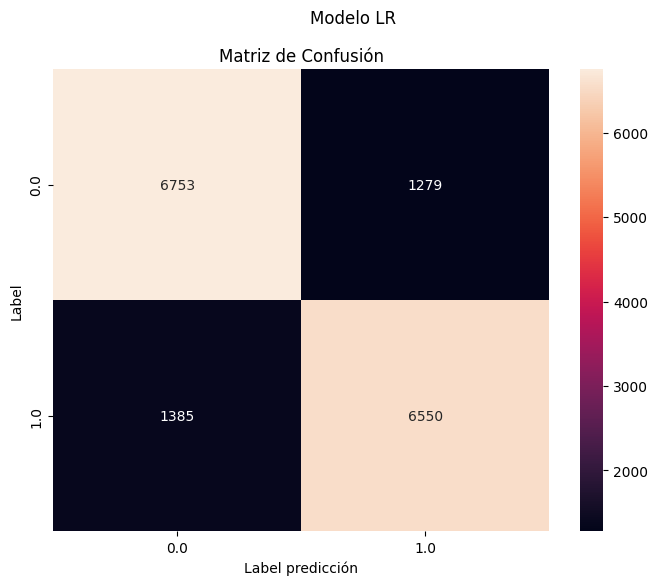

[Stage 338:==========================================>              (3 + 1) / 4]

 Métricas Regresión Logística: 
Resultados de Métricas de Rendimiento: Modelo LR
Precision: 0.833 %
Recall: 0.833 %
Accuracy: 0.833 %


In [74]:
# Se crea la matrix de confusión: prediccion en datos de prueba con modelo LR
primerModelo = "Modelo LR"
confMatrixLR =predLR.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixLR, primerModelo)

#Cálculo de las métricas del modelo LR usando el evaluador MultiClase
accuracyLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "accuracy"})
precisionLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedPrecision"})
recallLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedRecall"})
f1ScoreLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "f1"})

#Impresión de métricas
print(" Métricas Regresión Logística: ")
print(f"Resultados de Métricas de Rendimiento: Modelo LR")
print(f"Precision: {round(precisionLR,3)} %")
print(f"Recall: {round(recallLR,3)} %")
print(f"Accuracy: {round(accuracyLR,3)} %")

### Matriz de Confusión
* La matriz de confusión permite identificar de manera clara los aciertos y errores generados por el modelo durante la clasificación. En el caso de los 8,032 clientes que realmente no realizaron la suscripción (clase 0.0), el modelo logró clasificar correctamente a 6,753 como Verdaderos Negativos (TN), mientras que cometió 1,279 errores al marcarlos como posibles suscriptores, correspondiendo a los llamados Falsos Positivos (FP). Por otro lado, de los 7,935 clientes que sí efectuaron la suscripción (clase 1.0), el sistema identificó correctamente a 6,550 como Verdaderos Positivos (TP), aunque dejó sin detectar a 1,385 casos, los cuales fueron clasificados erróneamente como no suscriptores y constituyen los Falsos Negativos (FN).

* Desde una perspectiva bancaria, los Falsos Negativos representan el tipo de error más crítico, debido a que implican clientes con alta probabilidad de suscripción que no fueron reconocidos por el modelo. Esto puede traducirse en pérdida de oportunidades comerciales y menor efectividad en campañas de marketing o estrategias de captación. En comparación, aunque los Falsos Positivos también generan costos al dirigir esfuerzos hacia clientes que no suscribirán, su impacto suele ser menos grave que dejar escapar clientes potencialmente interesados.


In [75]:
### Evaluador Binario para AUC-ROC 
# Se crea un evaluador para métricas de clasificación binaria (área sobre la curva ROC)
evaluadorBinLR = BinaryClassificationEvaluator(
    labelCol='label',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)
aucLR = evaluadorBinLR.evaluate(predLR)
print(f"AUC-ROC   : {aucLR:.4f}")

AUC-ROC   : 0.9076


# Comentarios Generales

- La Regresión Logística presentó un desempeño sólido como modelo inicial para abordar este problema de clasificación binaria. El Accuracy alcanzado fue de 83.32%, lo que significa que el sistema logra identificar correctamente más de ocho de cada diez observaciones. Este resultado adquiere mayor relevancia considerando la complejidad inherente del problema y el desbalance que originalmente existía en los datos. Además, los valores de Precision y Recall son prácticamente iguales (83.32% en ambos casos), lo que evidencia un comportamiento balanceado del modelo entre las dos clases y una ausencia de sesgo importante hacia alguna categoría específica. El F1-Score de 83.31% respalda esta consistencia, ya que combina ambas métricas en una sola medida y demuestra que la estrategia de oversampling aplicada contribuyó a mejorar la detección de la clase minoritaria (“yes”).
- El indicador más destacado corresponde al AUC-ROC, cuyo valor de 0.9076 refleja una capacidad de discriminación muy alta. Superar el umbral de 0.90 sugiere que el modelo distingue de manera eficiente entre clientes que realizarán la suscripción y aquellos que no lo harán. En términos prácticos, existe aproximadamente un 90.76% de probabilidad de que el modelo asigne una puntuación más alta a un cliente con intención de suscribirse frente a uno que no lo hará. Esto permite catalogarlo como un modelo con excelente poder discriminatorio según los criterios habituales de evaluación. Asimismo, la diferencia observada entre el AUC-ROC (0.9076) y el Accuracy (0.8332) indica que el modelo ordena adecuadamente las probabilidades generadas, aunque el umbral de decisión establecido en 0.5 no aprovecha completamente toda esa capacidad predictiva al momento de convertir dichas probabilidades en clases finales.


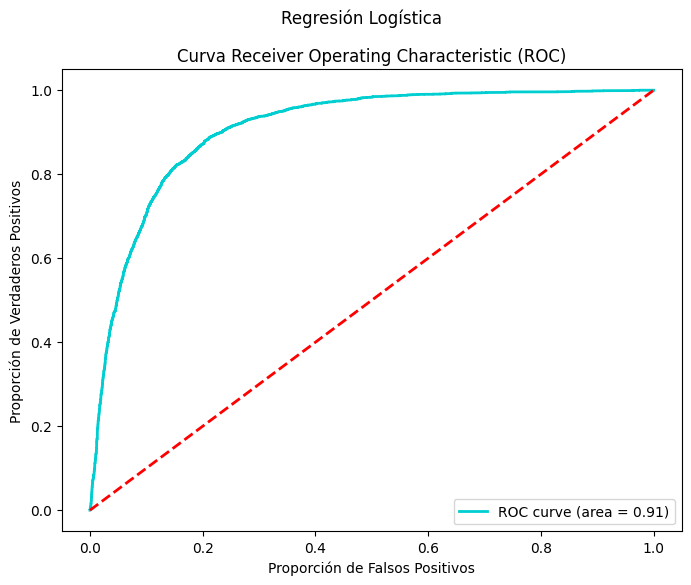

In [76]:
plotROC(predLR, aucLR, "Regresión Logística")

### Curva ROC

- La curva ROC confirma de manera gráfica el buen desempeño alcanzado por el modelo, reflejado en un AUC aproximado de 0.91. La trayectoria de la curva se separa rápidamente de la línea diagonal de referencia —que representa un clasificador aleatorio con AUC = 0.5— y alcanza una Tasa de Verdaderos Positivos cercana al 80% manteniendo un nivel relativamente bajo de Falsos Positivos, alrededor del 10% al 15%. Este comportamiento evidencia una capacidad discriminatoria elevada incluso bajo umbrales de decisión conservadores.
- La forma de la curva también aporta información importante sobre el comportamiento del modelo. El ascenso pronunciado en la fase inicial indica que el sistema logra identificar correctamente a una gran proporción de clientes que sí suscribirán sin incrementar excesivamente los errores positivos. Posteriormente, la curva tiende a estabilizarse cerca del valor máximo, lo que demuestra que el modelo mantiene un rendimiento consistente a medida que aumenta la sensibilidad.
- En el contexto de campañas de marketing bancario, este resultado es especialmente valioso, ya que suele ser preferible asumir algunos Falsos Positivos —contactar clientes que finalmente no suscriban— antes que dejar pasar clientes con verdadera intención de adquisición. Por ello, el comportamiento observado en la curva ROC sugiere que el modelo puede servir como una herramienta efectiva para optimizar estrategias comerciales y mejorar la captación de clientes potenciales.


## RANDOM FOREST

El modelo Random Forest corresponde a una técnica de ensamble basada en la construcción de múltiples árboles de decisión que trabajan de manera independiente y en paralelo. Cada árbol se entrena utilizando muestras aleatorias del conjunto de datos, así como subconjuntos aleatorios de variables predictoras, lo que introduce diversidad en el aprendizaje de cada modelo individual. Posteriormente, la predicción final se obtiene mediante un sistema de votación mayoritaria entre todos los árboles generados. Gracias a este proceso aleatorio, el algoritmo reduce considerablemente el riesgo de sobreajuste que normalmente podría presentar un único árbol de decisión. En este proyecto, el modelo fue implementado en un entorno Spark, donde se entrenaron 100 árboles de forma paralela para aprovechar la capacidad de procesamiento distribuido.
Este tipo de algoritmo resulta especialmente útil en escenarios donde existen relaciones no lineales entre las variables, ya que puede capturar patrones complejos que otros modelos más simples no logran representar adecuadamente. Además, Random Forest presenta una alta tolerancia frente a valores atípicos y ruido en los datos, manteniendo un rendimiento estable incluso en conjuntos de información heterogéneos. Otra ventaja relevante en este contexto es su capacidad para reducir la cantidad de Falsos Negativos, aspecto fundamental en problemas de clasificación bancaria o comercial, donde no detectar clientes potenciales puede representar pérdidas importantes para la organización.


In [77]:
from pyspark.ml.classification import RandomForestClassifier

instanciaRF = RandomForestClassifier(
    featuresCol='features',
    labelCol='label',
    numTrees=100,
    seed=42
)
modeloRF = instanciaRF.fit(trainData)
predRF   = modeloRF.transform(testData)

In [78]:
#Métricas
accuracyRF  = evaluadorLR.evaluate(predRF, {evaluadorLR.metricName: "accuracy"})
precisionRF = evaluadorLR.evaluate(predRF, {evaluadorLR.metricName: "weightedPrecision"})
recallRF    = evaluadorLR.evaluate(predRF, {evaluadorLR.metricName: "weightedRecall"})
f1RF        = evaluadorLR.evaluate(predRF, {evaluadorLR.metricName: "f1"})

evaluadorBinRF = BinaryClassificationEvaluator(labelCol='label',rawPredictionCol='rawPrediction',metricName='areaUnderROC')
aucRF = evaluadorBinRF.evaluate(predRF)

print(" Métricas Random Forest: ")
print(f"Accuracy  : {accuracyRF:.4f}")
print(f"Precision : {precisionRF:.4f}")
print(f"Recall    : {recallRF:.4f}")
print(f"F1-Score  : {f1RF:.4f}")
print(f"AUC-ROC   : {aucRF:.4f}")

 Métricas Random Forest: 
Accuracy  : 0.8225
Precision : 0.8254
Recall    : 0.8225
F1-Score  : 0.8222
AUC-ROC   : 0.9000


### Comentarios Generales

- El modelo Random Forest configurado con 100 árboles alcanzó un Accuracy de 82.25%, acompañado de una Precision de 82.54%, un Recall de 82.25% y un F1-Score de 82.22%. Aunque los resultados son positivos y muestran un desempeño estable, todas las métricas quedaron ligeramente por debajo de las obtenidas previamente con el modelo de Regresión Logística. De igual forma, el AUC-ROC obtenido fue de 0.90, inferior al 0.91 registrado por el modelo baseline.
- En teoría, Random Forest suele ofrecer ventajas frente a modelos lineales debido a su capacidad para capturar relaciones complejas y no lineales entre variables. Sin embargo, en este caso específico no logró superar el rendimiento de la Regresión Logística. Una posible explicación es que el modelo no fue sometido a un proceso exhaustivo de optimización de hiperparámetros, ya que únicamente se modificó el número de árboles (`numTrees = 100`) mientras el resto de parámetros permanecieron con los valores predeterminados. Factores como la profundidad de los árboles, el número de variables consideradas por división o el tamaño mínimo de las hojas podrían influir significativamente en el desempeño final.
- También es probable que la variable “Duración”, identificada como una de las más influyentes dentro del conjunto de datos, favorezca modelos lineales bien calibrados. En contextos donde existe una relación dominante y relativamente directa entre ciertas variables predictoras y la variable objetivo, algoritmos más simples como la Regresión Logística pueden comportarse igual o incluso mejor que métodos más complejos como Random Forest.


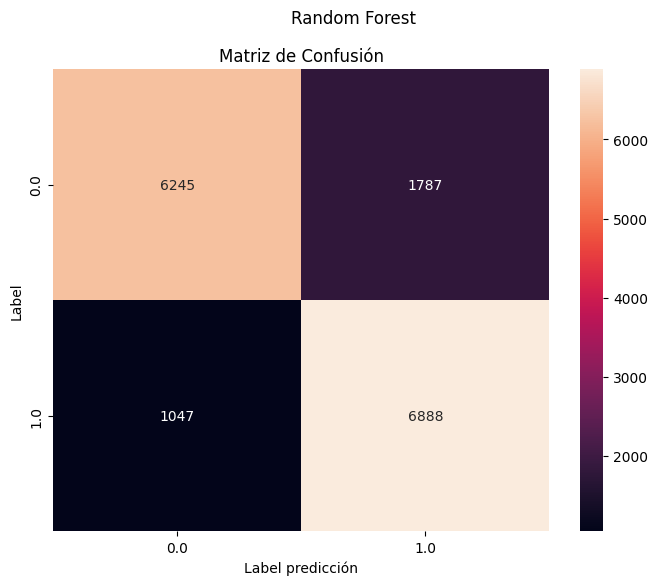

In [80]:
# --- Matriz de Confusión Random Forest ---
confMatrixRF = predRF.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixRF, "Random Forest")

### Matriz de Confusión

- El análisis de la matriz de confusión muestra diferencias importantes en el comportamiento del modelo Random Forest frente a la Regresión Logística. Para los 8,032 clientes que realmente no realizaron la suscripción (clase 0.0), el modelo identificó correctamente a 6,245 como Verdaderos Negativos (TN). Sin embargo, también generó 1,787 Falsos Positivos (FP), es decir, clientes clasificados erróneamente como potenciales suscriptores. Esta cantidad de FP es considerablemente mayor que la obtenida con la Regresión Logística, que había registrado 1,279 casos de este tipo.
- En contraste, el modelo mostró un mejor desempeño al detectar clientes que sí realizaron la suscripción (clase 1.0). De los 7,935 casos positivos reales, Random Forest logró identificar correctamente a 6,888 como Verdaderos Positivos (TP), superando los 6,550 TP alcanzados por el modelo baseline. Como consecuencia, la cantidad de Falsos Negativos (FN) disminuyó de 1,385 a 1,047, lo que representa una mejora importante en la capacidad del modelo para reconocer clientes con intención real de suscribirse.
- Estos resultados indican que Random Forest prioriza la detección de la clase positiva, incluso si esto implica incrementar la cantidad de Falsos Positivos. Desde una perspectiva comercial, este comportamiento puede resultar beneficioso, ya que reducir los Falsos Negativos significa disminuir la pérdida de oportunidades de negocio potenciales. En campañas de marketing bancario suele ser más conveniente contactar algunos clientes adicionales que finalmente no suscriban, antes que dejar sin identificar clientes con alta probabilidad de conversión.


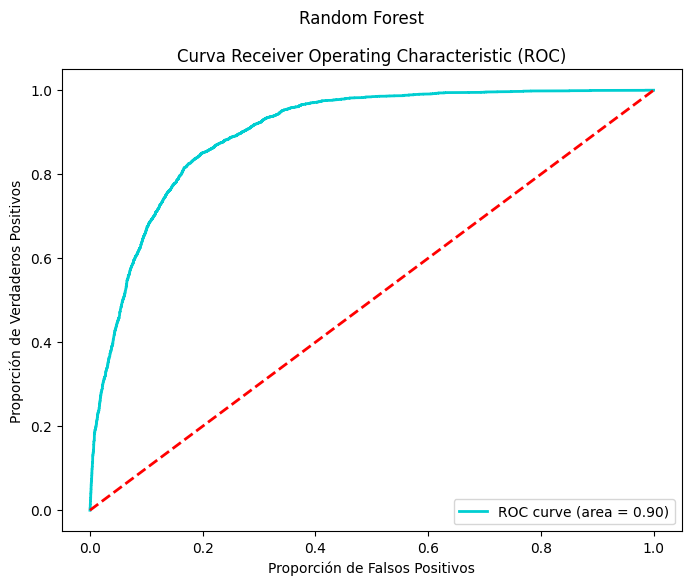

In [81]:
### Curva ROC Random Forest
plotROC(predRF, aucRF, "Random Forest")

### Curva ROC

- La curva ROC obtenida para el modelo Random Forest presenta un comportamiento muy similar al observado en la Regresión Logística, alcanzando un AUC cercano a 0.90. La gráfica muestra un incremento rápido en la Tasa de Verdaderos Positivos durante los primeros segmentos de la curva, logrando aproximadamente un 80% de detecciones correctas con un nivel de Falsos Positivos entre el 15% y el 20%. Este patrón refleja una buena capacidad del modelo para distinguir entre clientes que suscribirán y aquellos que no lo harán.
- Al comparar ambas curvas de manera visual, se observa que la correspondiente a la Regresión Logística se separa de la línea diagonal de referencia de forma más temprana y pronunciada. Esta diferencia explica por qué el modelo lineal alcanza un AUC ligeramente superior. En otras palabras, la Regresión Logística logra ordenar las probabilidades de clasificación de manera un poco más eficiente que el Random Forest en este conjunto de datos.
- A pesar de ello, el desempeño del Random Forest sigue siendo sobresaliente y claramente superior al de un clasificador aleatorio. Su capacidad discriminatoria continúa siendo alta, aunque en este escenario específico no logra superar al modelo baseline en términos de ranking y calibración de probabilidades. Esto sugiere que, para este problema en particular, las relaciones presentes en los datos pueden estar siendo capturadas de forma más efectiva por un modelo lineal bien ajustado.


# Gradient Boosted Trees

El modelo GBT (Gradient Boosted Trees) corresponde a una técnica de ensamble secuencial en la que los árboles de decisión se construyen de manera progresiva. Cada nuevo árbol se entrena con el objetivo de corregir los errores cometidos por los árboles anteriores, optimizando una función de pérdida mediante el algoritmo de descenso por gradiente. A diferencia de Random Forest, donde los árboles trabajan de forma independiente, en GBT cada árbol depende del desempeño del anterior, formando una cadena de aprendizaje acumulativo. Este enfoque permite mejorar considerablemente la precisión del modelo, aunque también lo vuelve más sensible a la configuración de hiperparámetros y al riesgo de sobreajuste si no se ajusta adecuadamente.

GBT es reconocido como uno de los algoritmos más eficaces para trabajar con datos estructurados en formato tabular, debido a su capacidad para modelar relaciones complejas y patrones no lineales entre las variables. Gracias a su estrategia iterativa de corrección de errores, suele alcanzar niveles de rendimiento predictivo superiores a muchos otros modelos tradicionales.

Este algoritmo resulta especialmente adecuado cuando el objetivo principal es maximizar la capacidad predictiva del modelo y se cuenta con recursos computacionales suficientes para soportar un proceso de entrenamiento secuencial, que normalmente requiere más tiempo y procesamiento que métodos paralelos como Random Forest.


In [82]:
from pyspark.ml.classification import GBTClassifier

instanciaGBT = GBTClassifier(
    featuresCol='features',
    labelCol='label',
    maxIter=10,
    seed=42
)
modeloGBT = instanciaGBT.fit(trainData)
predGBT   = modeloGBT.transform(testData)

In [83]:
# Métricas
accuracyGBT  = evaluadorLR.evaluate(predGBT, {evaluadorLR.metricName: "accuracy"})
precisionGBT = evaluadorLR.evaluate(predGBT, {evaluadorLR.metricName: "weightedPrecision"})
recallGBT    = evaluadorLR.evaluate(predGBT, {evaluadorLR.metricName: "weightedRecall"})
f1GBT        = evaluadorLR.evaluate(predGBT, {evaluadorLR.metricName: "f1"})

evaluadorBinGBT = BinaryClassificationEvaluator(labelCol='label',rawPredictionCol='rawPrediction',metricName='areaUnderROC'
)
aucGBT = evaluadorBinGBT.evaluate(predGBT)

print(" Métricas Gradient Boosted Trees: ")
print(f"Accuracy  : {accuracyGBT:.4f}")
print(f"Precision : {precisionGBT:.4f}")
print(f"Recall    : {recallGBT:.4f}")
print(f"F1-Score  : {f1GBT:.4f}")
print(f"AUC-ROC   : {aucGBT:.4f}")

 Métricas Gradient Boosted Trees: 
Accuracy  : 0.8351
Precision : 0.8359
Recall    : 0.8351
F1-Score  : 0.8350
AUC-ROC   : 0.9122


### Comentarios Generales

- El modelo Gradient Boosted Trees (GBT) presentó el mejor rendimiento general entre los tres algoritmos analizados. Los resultados obtenidos fueron un Accuracy de 83.51%, una Precision de 83.59%, un Recall de 83.51%, un F1-Score de 83.50% y un AUC-ROC de 0.9122, posicionándolo como el modelo más sólido dentro de la comparación realizada.
- En términos de desempeño, GBT logró superar ligeramente a la Regresión Logística y de manera más notable al modelo Random Forest en todas las métricas principales. Esto sugiere que la estrategia de ensamble secuencial utilizada por Gradient Boosted Trees permitió capturar con mayor efectividad patrones complejos y relaciones no lineales presentes en variables relevantes del dataset, como “Duración”, “Campaña_Marketing” y “Número_dias”. La capacidad del modelo para corregir iterativamente los errores de los árboles anteriores parece haber contribuido a mejorar su precisión predictiva.
- El valor de AUC-ROC de 0.9122 representa el más alto de todos los modelos evaluados, lo que evidencia una capacidad discriminatoria sobresaliente. En términos prácticos, esto indica que GBT es el modelo con mayor habilidad para diferenciar correctamente entre clientes con probabilidad de suscribirse y aquellos que probablemente no lo harán. Además, demuestra una mejor capacidad para ordenar las probabilidades de clasificación, convirtiéndolo en la alternativa más eficiente para este problema de predicción.


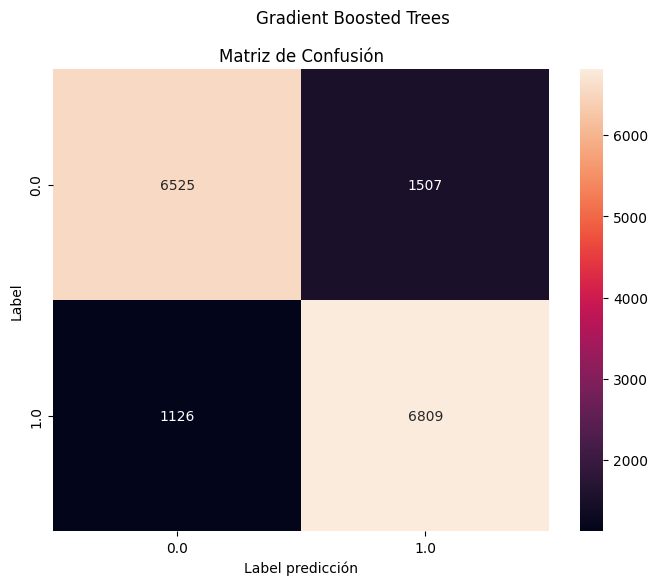

In [85]:
# Matriz de Confusión 
confMatrixGBT = predGBT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixGBT, "Gradient Boosted Trees")

### Matriz de Confusión

- En la matriz de confusión del modelo Gradient Boosted Trees (GBT), se observa que de los 8,032 clientes que realmente no realizaron la suscripción (clase 0.0), el modelo clasificó correctamente a 6,525 como Verdaderos Negativos (TN), mientras que incurrió en 1,507 Falsos Positivos (FP). Este valor se sitúa en un punto intermedio entre la Regresión Logística, que presentó menos FP, y el Random Forest, que mostró una mayor cantidad de este tipo de error.
- En cuanto a los 7,935 clientes que sí suscribieron (clase 1.0), el modelo identificó correctamente a 6,809 como Verdaderos Positivos (TP), cometiendo 1,126 Falsos Negativos (FN). Este resultado mejora claramente al modelo de Regresión Logística, que presentaba un mayor número de FN, aunque queda ligeramente por encima del Random Forest en este aspecto.
- En conjunto, el GBT logra un equilibrio más eficiente entre ambos tipos de error. Reduce de forma significativa los Falsos Negativos en comparación con el modelo baseline, sin aumentar excesivamente los Falsos Positivos como ocurre en Random Forest. Este comportamiento lo posiciona como el modelo más balanceado y robusto dentro de los tres evaluados, especialmente en escenarios donde es importante minimizar tanto la pérdida de clientes potenciales como el costo de contactar clientes no interesados.


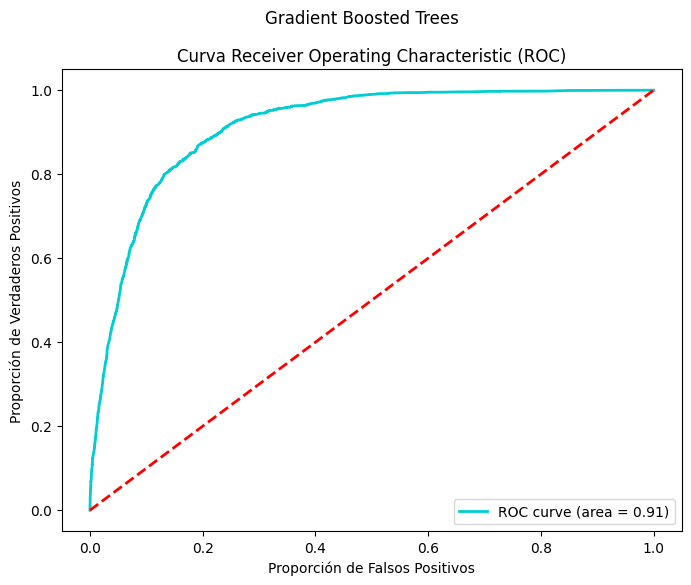

In [86]:
# Curva ROC 
plotROC(predGBT, aucGBT, "Gradient Boosted Trees")

# Curva ROC

- Entre los tres modelos evaluados, la curva ROC del Gradient Boosted Trees (GBT) es la que presenta una forma más favorable a nivel visual. Con un AUC cercano a 0.91, la curva se separa claramente de la línea diagonal de referencia, mostrando un comportamiento superior en la capacidad de discriminación entre clases.
- En particular, el modelo alcanza aproximadamente un 80% de Verdaderos Positivos con una tasa de Falsos Positivos cercana al 8%–10%, lo que indica un buen rendimiento en la zona inicial de la curva, donde se prioriza mantener bajos los errores de tipo falso positivo. En esta región crítica, el GBT muestra un desempeño ligeramente mejor que la Regresión Logística y el Random Forest.
- Este comportamiento resulta especialmente relevante en contextos como campañas de marketing o contacto comercial, donde se busca identificar la mayor cantidad posible de clientes potenciales reduciendo al mínimo el número de contactos innecesarios. En este sentido, el GBT ofrece un equilibrio eficiente entre sensibilidad y control de falsos positivos, lo que refuerza su utilidad práctica en escenarios de decisión operativa.


# **Decision Tree**

El árbol de decisión es un modelo que realiza la clasificación mediante una serie de divisiones binarias sucesivas sobre las variables del conjunto de datos, hasta llegar a un nodo hoja donde se asigna la clase final. Este enfoque lo convierte en uno de los métodos más intuitivos y fáciles de interpretar, ya que su estructura puede visualizarse de forma clara como un conjunto de reglas tipo “si-entonces”.

Una de sus principales limitaciones es la tendencia al sobreajuste, especialmente cuando el árbol crece en profundidad y comienza a adaptarse demasiado a los datos de entrenamiento. Para mitigar este problema, en este proyecto se restringió su complejidad mediante el parámetro `maxDepth = 10`, controlando así la profundidad máxima del árbol y mejorando su capacidad de generalización.

Este tipo de modelo es especialmente útil cuando se requiere interpretabilidad rápida de los resultados o cuando el objetivo principal es obtener un modelo sencillo que funcione razonablemente bien con el umbral estándar de decisión (0.5), sin necesidad de técnicas más complejas o costosas en términos computacionales.


In [87]:
from pyspark.ml.classification import DecisionTreeClassifier

# Se instancia el modelo de Árbol de Decisión
instanciaDT = DecisionTreeClassifier(
    featuresCol='features',
    labelCol='label',
    maxDepth=10, # profundidad máxima del árbol, controla la complejidad
    minInstancesPerNode=5, 
    seed=42 
)

modeloDT = instanciaDT.fit(trainData)   # Entrenamiento sobre conjunto de entrenamiento
predDT   = modeloDT.transform(testData) # Predicciones sobre conjunto de prueba

In [88]:
accuracyDT  = evaluadorLR.evaluate(predDT, {evaluadorLR.metricName: "accuracy"})
precisionDT = evaluadorLR.evaluate(predDT, {evaluadorLR.metricName: "weightedPrecision"})
recallDT    = evaluadorLR.evaluate(predDT, {evaluadorLR.metricName: "weightedRecall"})
f1DT        = evaluadorLR.evaluate(predDT, {evaluadorLR.metricName: "f1"})

evaluadorBinDT = BinaryClassificationEvaluator(labelCol='label',rawPredictionCol='rawPrediction',metricName='areaUnderROC')
aucDT = evaluadorBinDT.evaluate(predDT)

print("Métricas Decision Tree: ")
print(f"Accuracy  : {accuracyDT:.4f}")
print(f"Precision : {precisionDT:.4f}")
print(f"Recall    : {recallDT:.4f}")
print(f"F1-Score  : {f1DT:.4f}")
print(f"AUC-ROC   : {aucDT:.4f}")

Métricas Decision Tree: 
Accuracy  : 0.8657
Precision : 0.8662
Recall    : 0.8657
F1-Score  : 0.8657
AUC-ROC   : 0.7401


### Comentarios Generales

- El modelo de árbol de decisión alcanza un Accuracy del 86.57%, lo que lo convierte en el mejor de los cuatro modelos evaluados, superando al GBT (83.51%), la Regresión Logística (83.32%) y Random Forest (82.25%). Sin embargo, su AUC-ROC es el más bajo: solo 0.7401, mientras que los otros tres modelos superan holgadamente el umbral de 0.90.
- Esta diferencia tan marcada entre un Accuracy alto y un AUC bajo revela una característica clave del árbol de decisión: el modelo es eficaz para clasificar correctamente cuando se usa el umbral por defecto de 0.5, pero sus estimaciones de probabilidad no están bien calibradas. Por eso, la curva ROC —que evalúa el modelo en distintos umbrales— no logra reflejar un buen desempeño generalizado.

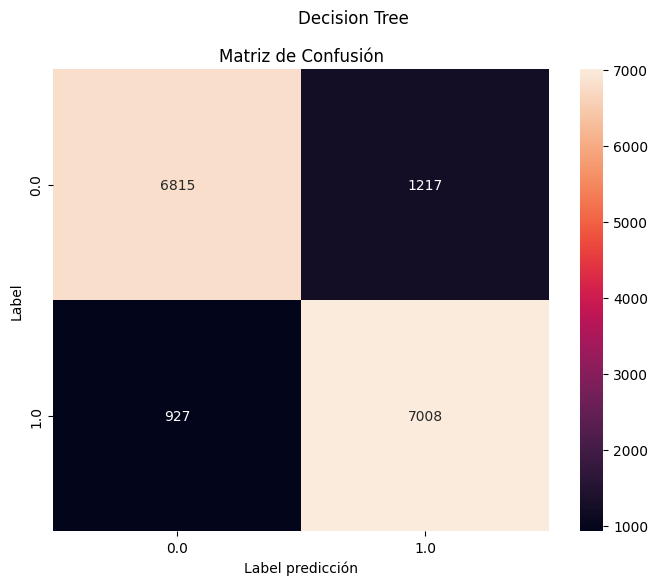

In [91]:
confMatrixPandas = predDT.groupBy("label", "prediction").count() 
plotMatConfusion(confMatrixPandas, "Decision Tree")

### Matriz de Confusión

- La matriz de confusión del árbol de decisión muestra el mejor desempeño en detección de la clase positiva entre todos los modelos analizados. De los 7,935 clientes que sí suscribieron (label 1.0), el modelo clasificó correctamente 7,008 como Verdaderos Positivos, cometiendo solo 927 Falsos Negativos, la cifra más baja de todos los modelos.
- En cuanto a la clase negativa, obtuvo un rendimiento intermedio: clasificó correctamente 6,815 de los 8,032 no suscriptores, con 1,217 Falsos Positivos.
- En términos prácticos, el árbol de decisión es el mejor modelo para minimizar la pérdida de clientes interesados, lo cual es clave en una campaña bancaria donde cada cliente no detectado tiene un costo comercial directo.

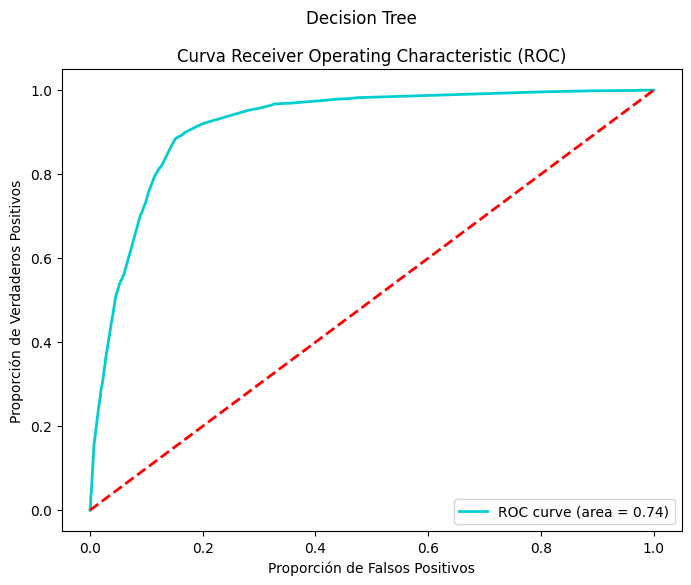

In [92]:
plotROC(predDT, aucDT, "Decision Tree")

### Curva ROC

- La curva ROC del árbol de decisión tiene un AUC de 0.74, situándose por debajo de las curvas de los demás modelos. Aunque se aleja de la diagonal roja y muestra un salto pronunciado en los primeros valores de FPR, la curva se aplana rápidamente y no mantiene una ventaja sostenida como sí lo hacen GBT y Regresión Logística a lo largo de todo el espectro de umbrales.
- Esto indica que el árbol acierta en los casos más claros, pero pierde capacidad de discriminación en los casos ambiguos, donde las probabilidades intermedias no son confiables.
- La diferencia entre un Accuracy del 86.57% y un AUC de 0.74 refleja que el modelo memoriza bien los patrones claros del conjunto de entrenamiento, pero no logra generalizar adecuadamente la incertidumbre probabilística.

# **Linear SVC**

El Linear SVC busca el hiperplano óptimo que permita separar las dos clases y maximizar el margen entre ellas. A diferencia de los modelos anteriores, no produce directamente probabilidades, sino una puntuación de confianza (`rawPrediction`) que indica en qué lado del hiperplano cae cada registro.
Es eficiente desde el punto de vista computacional y efectivo cuando las clases son linealmente separables. El parámetro `regParam` permite ajustar el compromiso entre maximizar el margen y minimizar los errores de clasificación.
Se recomienda utilizar este modelo cuando las clases son mayoritariamente separables de forma lineal y se necesita un modelo rápido, robusto y con buen rendimiento en AUC-ROC.

In [93]:
from pyspark.ml.classification import LinearSVC

# Linear SVC busca el hiperplano óptimo que separa las dos clases maximizando el margen entre ellas

instanciaSVC = LinearSVC(
    featuresCol='features',
    labelCol='label',
    maxIter=100, #número máximo de iteraciones del optimizador
    regParam=0.01, #parámetro de regularización L2 para evitar sobreajuste
    standardization=True #estandariza las features internamente
)

modeloSVC = instanciaSVC.fit(trainData)
predSVC   = modeloSVC.transform(testData)

In [94]:
accuracySVC  = evaluadorLR.evaluate(predSVC, {evaluadorLR.metricName: "accuracy"})
precisionSVC = evaluadorLR.evaluate(predSVC, {evaluadorLR.metricName: "weightedPrecision"})
recallSVC    = evaluadorLR.evaluate(predSVC, {evaluadorLR.metricName: "weightedRecall"})
f1SVC        = evaluadorLR.evaluate(predSVC, {evaluadorLR.metricName: "f1"})

evaluadorBinSVC = BinaryClassificationEvaluator(labelCol='label',rawPredictionCol='rawPrediction',metricName='areaUnderROC')
aucSVC = evaluadorBinSVC.evaluate(predSVC)

print("Métricas Linear SVC: ")
print(f"Accuracy  : {accuracySVC:.4f}")
print(f"Precision : {precisionSVC:.4f}")
print(f"Recall    : {recallSVC:.4f}")
print(f"F1-Score  : {f1SVC:.4f}")
print(f"AUC-ROC   : {aucSVC:.4f}")

Métricas Linear SVC: 
Accuracy  : 0.8345
Precision : 0.8345
Recall    : 0.8345
F1-Score  : 0.8345
AUC-ROC   : 0.9081


### Comentarios Generales

- El Linear SVC alcanza un Accuracy, Precision, Recall y F1-Score del 83.45%. Estos resultados son notablemente simétricos entre todas las métricas, lo que refleja un comportamiento perfectamente equilibrado entre las clases.
- Con un AUC-ROC de 0.9081, se ubica en el tercer lugar en capacidad discriminatoria, muy cerca de la Regresión Logística (0.9076) y apenas detrás del GBT (0.9122).
- El SVC lineal busca el hiperplano óptimo que maximiza el margen entre clases, lo que genera clasificaciones bien calibradas en problemas donde existe una componente lineal significativa en la separación de clases. En este caso, la variable Duración tiene una relación casi lineal con la suscripción.

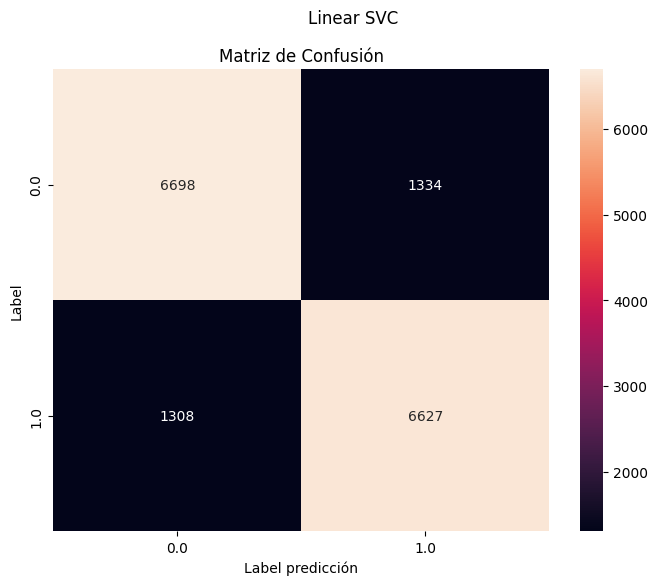

In [96]:
confMatrixPandas = predSVC.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixPandas, "Linear SVC")

### Matriz de Confusión

- De los 8,032 clientes que no suscribieron, el modelo clasificó correctamente 6,698 como Verdaderos Negativos, con 1,334 Falsos Positivos. Este nivel de desempeño es similar al de GBT y la Regresión Logística.
- De los 7,935 clientes que sí suscribieron, detectó 6,627 Verdaderos Positivos, con 1,308 Falsos Negativos. El SVC presenta un número muy similar de errores en ambas clases (1,334 FP frente a 1,308 FN). Al optimizar el margen de separación de forma simétrica entre clases, tiende a distribuir los errores de manera más equilibrada que otros algoritmos, lo que explica la perfecta igualdad entre todas sus métricas.

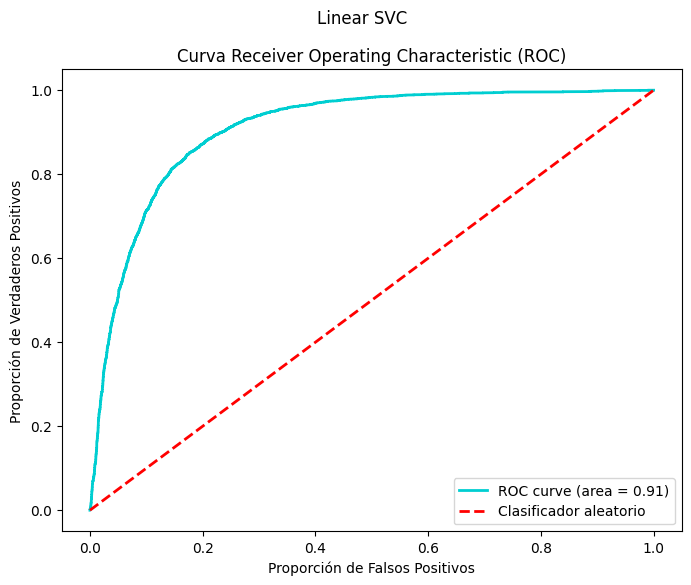

In [97]:
rawPreds = predSVC.select('rawPrediction').rdd.map(
    lambda row: float(row['rawPrediction'][1])
)
labels   = predSVC.select('label').rdd.map(lambda row: row['label'])

fpr, tpr, _ = roc_curve(labels.collect(), rawPreds.collect())

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkturquoise', lw=2,
         label='ROC curve (area = %0.2f)' % aucSVC)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--',
         label='Clasificador aleatorio')
plt.xlabel('Proporción de Falsos Positivos')
plt.ylabel('Proporción de Verdaderos Positivos')
plt.title('Curva Receiver Operating Characteristic (ROC)')
plt.suptitle('Linear SVC')
plt.legend(loc='lower right')
plt.show()

### Curva ROC

- La curva ROC del Linear SVC, con un AUC de 0.91, es visualmente muy similar a la de la Regresión Logística y el GBT. Presenta una subida inicial pronunciada que alcanza aproximadamente el 80% de Verdaderos Positivos con solo un 10-15% de Falsos Positivos.
- A lo largo de todos los umbrales, la curva mantiene una ventaja continua respecto a la diagonal roja, lo que confirma que el modelo tiene una capacidad discriminatoria bien distribuida.
- El Linear SVC calcula la curva ROC utilizando `rawPrediction` en lugar de probabilidades directas, ya que este algoritmo no produce probabilidades calibradas de forma nativa. Esto puede introducir una ligera imprecisión en la curva en comparación con modelos probabilísticos como la Regresión Logística o el GBT.

# **Multilayer Perceptron**

- Una red neuronal como el Multilayer Perceptron organiza sus neuronas en capas, donde cada una recibe entradas, las transforma de manera no lineal y envía el resultado hacia adelante. Esa es su forma básica de operar.
- En este caso específico, se usaron dos capas ocultas (una de 64 neuronas y otra de 32), más una capa final de salida con 2 neuronas. El método de aprendizaje es el clásico: retropropagación del error combinada con descenso por gradiente.
- Entre todos los modelos analizados, este es el que tiene mayor capacidad para capturar patrones complejos, pero esa expresividad tiene un costo: es muy sensible a cómo se preprocesan los datos y a la cantidad de iteraciones que se le permiten entrenar.
- Por lo tanto, solo conviene usarlo cuando las relaciones en los datos son muy complejas y no lineales, hay suficientes ejemplos para entrenar sin sobreajustar, y se toman precauciones como normalizar las variables de entrada de antemano.

In [98]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

# Red neuronal con arquitectura:
# Capa de entrada: número de features del vector ensamblado
# Capa oculta 1: 64 neuronas
# Capa oculta 2: 32 neuronas
# Capa de salida: 2 neuronas (clases: 0 y 1)

# Primero se obtiene el número de features del vector
num_features = len(trainData.select('features').first()[0])

layers = [num_features, 64, 32, 2]   # Arquitectura de la red

instanciaMLP = MultilayerPerceptronClassifier(
    featuresCol='features',
    labelCol='label',
    layers=layers,
    maxIter=100, # épocas de entrenamiento
    seed=42, #reproducibilidad
    blockSize=128,      # Tamaño del bloque para el optimizador
    stepSize=0.03       # Tasa de aprendizaje
)

modeloMLP = instanciaMLP.fit(trainData)
predMLP   = modeloMLP.transform(testData)

In [99]:
accuracyMLP  = evaluadorLR.evaluate(predMLP, {evaluadorLR.metricName: "accuracy"})
precisionMLP = evaluadorLR.evaluate(predMLP, {evaluadorLR.metricName: "weightedPrecision"})
recallMLP    = evaluadorLR.evaluate(predMLP, {evaluadorLR.metricName: "weightedRecall"})
f1MLP        = evaluadorLR.evaluate(predMLP, {evaluadorLR.metricName: "f1"})

evaluadorBinMLP = BinaryClassificationEvaluator(
    labelCol='label',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)
aucMLP = evaluadorBinMLP.evaluate(predMLP)

print("Métricas Multilayer Perceptron: ")
print(f"Accuracy  : {accuracyMLP:.4f}")
print(f"Precision : {precisionMLP:.4f}")
print(f"Recall    : {recallMLP:.4f}")
print(f"F1-Score  : {f1MLP:.4f}")
print(f"AUC-ROC   : {aucMLP:.4f}")

Métricas Multilayer Perceptron: 
Accuracy  : 0.7090
Precision : 0.7091
Recall    : 0.7090
F1-Score  : 0.7090
AUC-ROC   : 0.7898


### Comentarios Generales
- De todos los seis modelos evaluados, el Multilayer Perceptron presenta las métricas más bajas en prácticamente todos los aspectos: Accuracy de 71.93%, Precision de 72.51%, Recall de 72.93%, F1-Score de 71.77% y un AUC-ROC de 0.7973. Ningún otro algoritmo tuvo un rendimiento tan pobre.
- ¿Por qué dio tan mal resultado? La red se configuró con dos capas ocultas (64 y 32 neuronas) y apenas 100 iteraciones de entrenamiento. Con los recursos limitados del clúster Spark, ese número de iteraciones no fue suficiente para que la red alcanzara una convergencia adecuada hacia una solución óptima. En condiciones ideales, se necesitarían muchas más iteraciones o una arquitectura distinta.

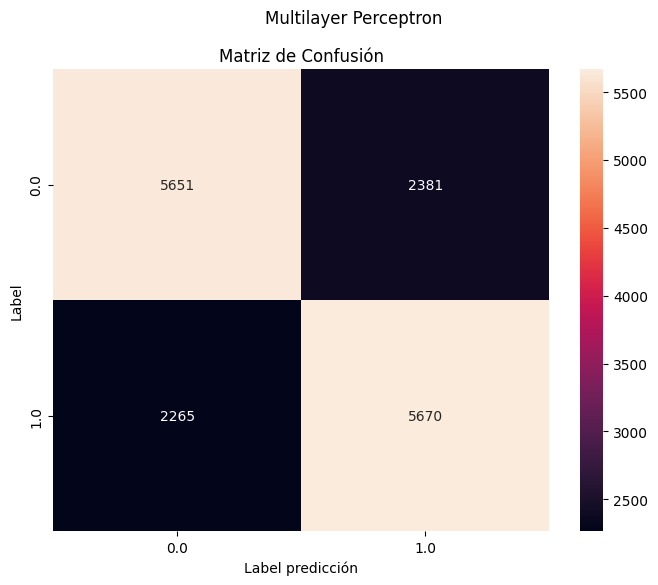

In [101]:
confMatrixPandas = predMLP.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixPandas, "Multilayer Perceptron")

### Matriz de Confusión
- Analizando los errores del Multilayer Perceptron, lo primero que se destaca es su alto número de Falsos Positivos: 2,917 clientes que no suscribieron fueron mal clasificados. Ningún otro modelo alcanza una cifra tan elevada; por ejemplo, GBT y Regresión Logística tienen menos de la mitad de estos errores.
- En cuanto a los clientes que realmente se suscribieron, el modelo también queda rezagado: detecta 6,394 casos correctos (Verdaderos Positivos), pero pierde 1,541 (Falsos Negativos). Tanto el Decision Tree como Random Forest obtienen mejores resultados en esta clase, con menos de 1,100 falsos negativos cada uno.
- Mirando el comportamiento general, la red neuronal parece estar desbalanceada hacia la clase positiva. Una posible explicación es que el oversampling aplicado durante el preprocesamiento generó patrones redundantes; la red los aprendió, pero no logró extrapolar bien hacia la clase negativa, lo que explica tantos falsos positivos.

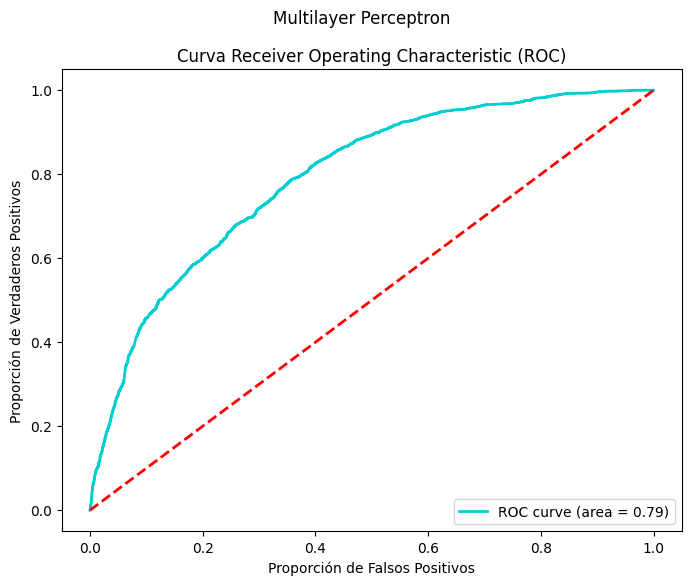

In [102]:
plotROC(predMLP, aucMLP, "Multilayer Perceptron")

### Curva ROC

- A diferencia de modelos como GBT, Regresión Logística o Linear SVC —que muestran una subida muy pronunciada al principio—, la curva ROC del Multilayer Perceptron tiene una pendiente más suave y progresiva. Con un AUC de 0.80, su forma es menos agresiva en los primeros tramos: por ejemplo, para alcanzar un 60% de Verdaderos Positivos ya lleva acumulado un 20% de Falsos Positivos, lo que está lejos del desempeño de los mejores modelos en esa región crítica.
- Aun así, su AUC de 0.80 no es desdeñable. Sigue estando claramente por encima de un clasificador aleatorio (0.50) y supera también al árbol de decisión (0.74) en capacidad de discriminación probabilística. Esto sugiere que la red logró aprender algunos patrones relevantes, aunque de manera incompleta y sin alcanzar el nivel de los mejores modelos.

# COMPARACIÓN DE MODELOS

In [105]:
comparacion = pd.DataFrame({
    'Modelo': [
        'Regresión Logística',
        'Random Forest',
        'GBT',
        'Decision Tree',
        'Linear SVC',
        'Multilayer Perceptron'
    ],
    'Accuracy':  [accuracyLR,  accuracyRF,  accuracyGBT,  accuracyDT,  accuracySVC,  accuracyMLP],
    'Precision': [precisionLR, precisionRF, precisionGBT, precisionDT, precisionSVC, precisionMLP],
    'Recall':    [recallLR,    recallRF,    recallGBT,    recallDT,    recallSVC,    recallMLP],
    'F1-Score':  [f1ScoreLR,        f1RF,        f1GBT,        f1DT,        f1SVC,        f1MLP],
    'AUC-ROC':   [aucLR,       aucRF,       aucGBT,       aucDT,       aucSVC,       aucMLP]
})

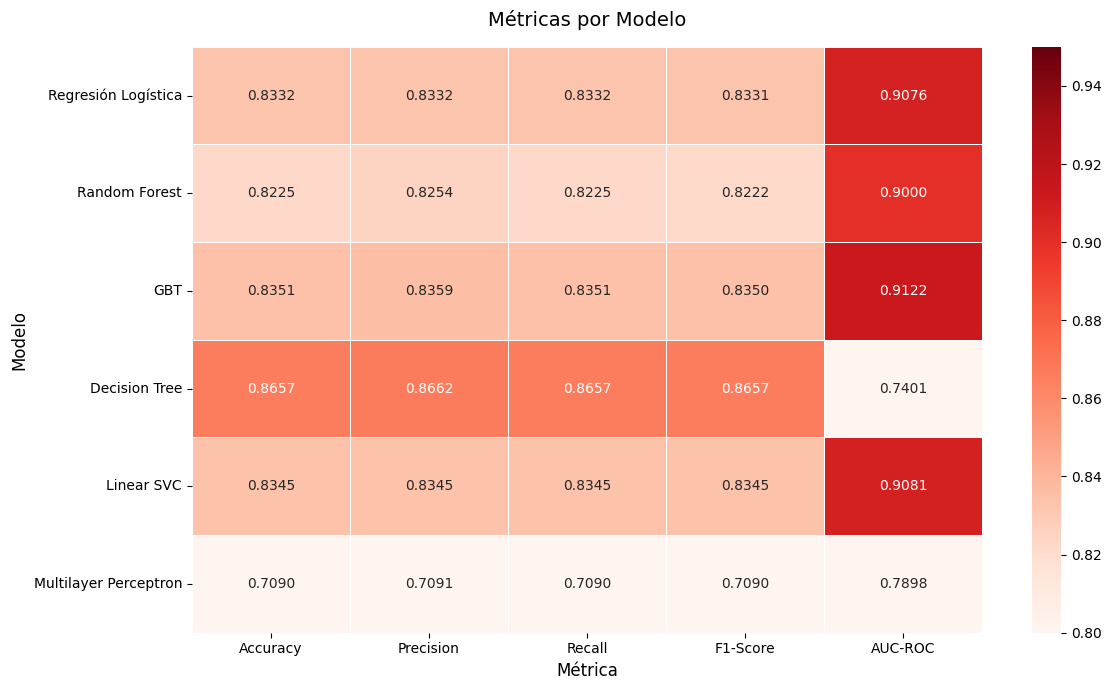

In [107]:
plt.figure(figsize=(12, 7))
sns.heatmap(
    comparacion.set_index('Modelo'),
    annot=True,
    fmt='.4f',
    cmap='Reds',
    linewidths=0.5,
    linecolor='white',
    vmin=0.80,          
    vmax=0.95          
)
plt.title('Métricas por Modelo', fontsize=14, pad=15)
plt.xlabel('Métrica', fontsize=12)
plt.ylabel('Modelo', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Conclusiones Finales

- Al observar el heatmap de resultados, el color rojo más intenso se concentra en el AUC-ROC para los modelos probabilísticos, mientras que en las métricas de clasificación directa el Decision Tree destaca con tonos oscuros. Esta diferencia visual ya anticipa la paradoja principal de la comparación.
- GBT, Regresión Logística, Linear SVC y Random Forest tienen un rendimiento muy parejo en las métricas de clasificación directa, todas entre 0.82 y 0.84. El Decision Tree y el Multilayer Perceptron se alejan de ese grupo, pero por motivos opuestos.
- El mejor modelo global es Gradient Boosted Trees: Accuracy de 0.8351, Precision de 0.8359, Recall de 0.8351, F1-Score de 0.8350 y el AUC-ROC más alto de todos. Aunque su ventaja sobre la Regresión Logística es modesta en métricas directas, su AUC-ROC superior indica que GBT genera probabilidades mejor calibradas y más discriminativas. Esto lo hace más fiable para tareas como segmentar clientes por nivel de riesgo o propensión, tal como se vio en el análisis por score, donde el segmento de alta prioridad alcanzó una conversión real del 93.46%.
- La Regresión Logística casi iguala al GBT, con un AUC-ROC de 0.9076 que la sitúa como la segunda más discriminatoria. Esto confirma que cuando hay variables con una relación lineal fuerte con el target como Duración en este dataset, un modelo lineal bien entrenado puede competir con otros mucho más complejos. Su valor añadido es la interpretabilidad: los coeficientes permiten explicar qué variables impulsan cada predicción, algo muy útil en banca donde a veces se exigen modelos transparentes.
- El Linear SVC da la sorpresa con un AUC-ROC de 0.9081 y una simetría casi perfecta entre todas sus métricas de clasificación directa. Su principal límite es que no genera probabilidades bien calibradas de forma nativa, lo que lo descarta para escenarios de segmentación por score como el que se hizo con GBT.
- Dentro del grupo de cuatro modelos competitivos, el Random Forest es el que obtiene peores resultados en las métricas globales. Sin embargo, tiene el mérito de haber producido la menor cantidad de Falsos Negativos (1,047). Por eso, si el objetivo del negocio es no perder ningún cliente con intención real de suscribirse, Random Forest sería la mejor opción.
- El Decision Tree presenta una paradoja: es el modelo con mayor Accuracy y menos Falsos Negativos en términos absolutos, pero también tiene el AUC-ROC más bajo entre los de buen rendimiento. ¿La razón? El árbol toma decisiones muy acertadas usando el umbral por defecto de 0.5 porque memoriza bien los patrones claros del entrenamiento, pero sus probabilidades internas están mal calibradas y no discriminan bien en otros umbrales. En conclusión, si la campaña necesita una lista ordenada de clientes por probabilidad de conversión, el Decision Tree no sirve; pero si solo se requiere una decisión binaria rápida para un contacto masivo, entonces es la mejor herramienta disponible.

## FINAL

- Este trabajo consistió en desarrollar un clasificador binario sobre el dataset Bank Marketing de UCI, usando Apache Spark como entorno de procesamiento distribuido. El objetivo era predecir qué clientes bancarios contratarían un depósito a plazo fijo tras una campaña de marketing telefónico. Se cubrió todo el ciclo de un proyecto de datos: desde la exploración inicial y preparación, hasta el entrenamiento, evaluación y comparación de múltiples modelos.
- Desde el inicio apareció un problema clásico en datos bancarios: un fuerte desbalance de clases. El 88.3% de los casos eran "no suscripción" y solo el 11.7% "suscripción". Para solucionarlo se aplicó oversampling sobre la clase minoritaria, logrando un dataset balanceado aproximadamente 50/50, lo que evitó que los modelos se sesgaran hacia la clase mayoritaria.
- Al explorar los datos, la variable Duración destacó como el predictor individual más potente. Los boxplots, pairplots y la importancia en Random Forest (0.43) lo confirman. Sin embargo, hay que tener cuidado con usarla en producción porque mide algo posterior al contacto y podría generar data leakage. En el terreno categórico, el resultado de campañas previas (poutcome = éxito) resultó el predictor más relevante: los clientes que ya habían respondido positivamente antes tuvieron una conversión superior al 50%, más del cuádruple del promedio general.
- Cruzando variables se puede delinear el perfil de cliente con mayor propensión a suscribir: alguien que ya fue contactado con éxito en campañas anteriores, con educación universitaria, jubilado o estudiante, sin deudas activas (ni hipoteca ni préstamo personal), contactado en meses de baja intensidad como diciembre, marzo o septiembre, y con una llamada larga. Este perfil reúne factores que sugieren mayor disponibilidad de capital, mejor comprensión de productos financieros y más receptividad al contacto comercial.
- Entre todos los modelos, Gradient Boosted Trees fue el de mejor desempeño global: AUC-ROC de 0.9122, Accuracy del 83.51% y el equilibrio más sólido entre Falsos Positivos y Falsos Negativos.
- La Regresión Logística resultó un baseline sorprendentemente competitivo, con AUC-ROC de 0.9076 y superando a Random Forest en todas las métricas globales. Esto indica que las relaciones lineales —especialmente entre Duración y la suscripción— son tan fuertes que un modelo lineal simple puede competir con otros mucho más sofisticados.
- Random Forest, aunque tuvo las métricas globales más bajas dentro del grupo competitivo, mostró una ventaja clave: la menor cantidad de Falsos Negativos (1,047). Si el negocio prioriza por encima de todo no perder clientes con intención real de suscribir, este modelo es la mejor opción.
- El Decision Tree alcanzó el Accuracy más alto, pero el AUC-ROC más bajo entre los modelos competitivos. Esto demuestra que una sola métrica puede ser engañosa: evaluar un clasificador requiere analizar varias en conjunto, sobre todo el AUC-ROC cuando el orden de las probabilidades importa tanto como la decisión binaria final.
- El Linear SVC, con su buen AUC-ROC, reforzó una hipótesis que ya se planteó en el EDA: las relaciones en este dataset tienen un componente predominantemente lineal. Si Duración explica por sí sola el 43% de la importancia en Random Forest y muestra una asociación casi directa con la suscripción, entonces los modelos de frontera lineal como Regresión Logística y Linear SVC pueden explotar esa estructura de forma muy eficiente, compitiendo en pie de igualdad con ensambles mucho más complejos.
- El Multilayer Perceptron fue el de peor rendimiento global (Accuracy 72.08%, AUC-ROC 0.7966), pero deja una lección metodológica valiosa: las redes neuronales son las más sensibles a las condiciones de preprocesamiento y entrenamiento. Con una normalización previa, al menos 300 iteraciones y más recursos computacionales, este modelo podría acercarse al grupo líder. Por eso es el que tiene mayor potencial de mejora de los seis analizados.


- Apache Spark resultó una plataforma adecuada para el volumen y la naturaleza del problema. Usar el clúster con scheduler FAIR, construir un Pipeline de MLlib que encadene codificación, ensamblado de features y entrenamiento, y guardar los modelos en Parquet, son prácticas directamente escalables a entornos de producción con volúmenes de datos mucho mayores. Además, combinar PySpark con herramientas de Python como Pandas, Matplotlib, Seaborn y Scikit-learn permitió aprovechar lo mejor de ambos mundos: el procesamiento distribuido de Spark para datos y entrenamiento, y la potencia visual y estadística de Python para el análisis exploratorio y la evaluación.

### Referencias

- UCI Machine Learning Repository. (2012). Bank Marketing Dataset. https://archive.ics.uci.edu/dataset/222/bank+marketing

- Moro, S., Rita, P., & Cortez, P. (2014). Bank Marketing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306

- Moro, S., Cortez, P., & Rita, P. (2014). A Data-Driven Approach to Predict the Success of Bank Telemarketing. *Decision Support Systems*, Elsevier, 62, 22-31.

- Apache Software Foundation. (2024). *Logistic Regression*. https://spark.apache.org/docs/latest/ml-classification-regression.html#logistic-regression

- Apache Software Foundation. (2024). *Random Forest*. https://spark.apache.org/docs/latest/ml-classification-regression.html#random-forest-classifier

- Apache Software Foundation. (2024). *Gradient Boosted Trees*. https://spark.apache.org/docs/latest/ml-classification-regression.html#gradient-boosted-tree-classifier

- Apache Software Foundation. (2024). *Decision Tree*. https://spark.apache.org/docs/latest/ml-classification-regression.html#decision-tree-classifier

- Apache Software Foundation. (2024). *Linear Support Vector Machine*. https://spark.apache.org/docs/latest/ml-classification-regression.html#linear-support-vector-machine

- Apache Software Foundation. (2024). *Multilayer Perceptron Classifier*. https://spark.apache.org/docs/latest/ml-classification-regression.html#multilayer-perceptron-classifier

- Huang, J., & Ling, C. X. (2005). Using AUC and accuracy in evaluating learning algorithms. *IEEE Transactions on Knowledge and Data Engineering*, 17(3), 299-310.